# Blood Cell Anomaly Detection

## Detecção de Anomalias em Células Sanguíneas com Machine Learning

**Baseado no paper:** Deltadahl et al. (2025). *Deep Generative Classification of Blood Cell Morphology.* Nature Machine Intelligence.  
**DOI:** 10.1038/s42256-025-01122-7

---

### Objetivo

Este notebook realiza a análise exploratória e a construção de modelos de Machine Learning para:

1. **Classificação Binária** — Normal vs Anomalia
2. **Classificação Multi-classe** — 19 tipos celulares
3. **Predição por Doença** — Leucemia, Anemia, Infecção, etc.

### Dataset

- **5.880 registros** de células sanguíneas
- **19 tipos celulares** (7 normais + 12 anormais)
- **36 features** (morfologia, cor, CBC clínico, aquisição, scores IA)

---

## 1. Importação de Bibliotecas

In [102]:
# Manipulação de dados
import pandas as pd
import numpy as np

# Visualização
import matplotlib.pyplot as plt
import seaborn as sns

# Pré-processamento
from sklearn.model_selection import train_test_split, cross_val_score, StratifiedKFold
from sklearn.preprocessing import LabelEncoder, StandardScaler
from sklearn.utils.class_weight import compute_class_weight

# Modelos
from sklearn.ensemble import RandomForestClassifier, GradientBoostingClassifier
from sklearn.linear_model import LogisticRegression
from sklearn.svm import SVC
from sklearn.neighbors import KNeighborsClassifier

# Métricas
from sklearn.metrics import (
    classification_report, confusion_matrix, roc_auc_score,
    accuracy_score, f1_score, roc_curve, auc,
    ConfusionMatrixDisplay
)

# Configurações
import warnings
warnings.filterwarnings('ignore')
plt.style.use('seaborn-v0_8-darkgrid')
pd.set_option('display.max_columns', 40)

RANDOM_STATE = 42
print('Bibliotecas carregadas com sucesso!')

Bibliotecas carregadas com sucesso!


## 2. Carregamento dos Dados

In [103]:
# Carregar os 3 arquivos CSV
df = pd.read_csv('cell_Blood/blood_cell_anomaly_detection.csv')
df_reference = pd.read_csv('cell_Blood/cell_type_reference.csv')
df_benchmark = pd.read_csv('cell_Blood/cytodiffusion_benchmark_scores.csv')

print(f'Dataset principal: {df.shape[0]} linhas x {df.shape[1]} colunas')
print(f'Referência celular: {df_reference.shape[0]} tipos celulares')
print(f'Benchmark scores:   {df_benchmark.shape[0]} registros')

Dataset principal: 5880 linhas x 36 colunas
Referência celular: 19 tipos celulares
Benchmark scores:   10 registros


In [104]:
# Primeiras linhas do dataset principal
df.head()

,cell_id,cell_type,anomaly_label,disease_category,cell_diameter_um,nucleus_area_pct,chromatin_density,cytoplasm_ratio,circularity,eccentricity,granularity_score,lobularity_score,membrane_smoothness,cell_area_px,perimeter_px,mean_r,mean_g,mean_b,stain_intensity,patient_age_group,patient_sex,wbc_count_per_ul,rbc_count_millions_per_ul,hemoglobin_g_dl,hematocrit_pct,platelet_count_per_ul,mcv_fl,mchc_g_dl,dataset_source,staining_protocol,microscope_model,magnification_x,image_resolution_px,cytodiffusion_anomaly_score,cytodiffusion_classification_confidence,labeller_confidence_score
0,CELL_005371,Hypersegmented_Neutrophil,1,Infection,15.18,58.8,0.542,0.301,0.563,0.529,4.11,6.6,0.800,445,90,215,141,160,0.555,Elderly,F,6352,4.44,11.7,43.4,257383,85.5,31.4,CytoData,Giemsa,Zeiss_Axio,100,224,0.7649,0.5726,0.5670
1,CELL_005300,Hypersegmented_Neutrophil,1,Infection,16.47,73.6,0.583,0.365,0.859,0.443,2.50,6.3,0.737,383,61,189,136,169,0.692,Elderly,M,7709,4.90,13.9,42.2,302274,92.5,35.0,PBC_Dataset,Wright,Zeiss_Axio,100,224,0.8472,0.7150,0.7273
2,CELL_000200,Neutrophil,0,Normal_WBC,13.41,55.5,0.448,0.376,0.781,0.407,3.01,3.2,0.790,418,52,193,150,203,0.593,Adult,M,7451,5.72,16.1,39.2,229996,76.3,33.0,CytoData,Wright,Leica_DM2000,100,512,0.0313,0.9225,0.9623
3,CELL_003269,Normal_RBC,0,Normal_RBC,7.36,0.0,0.000,1.000,0.880,0.167,0.43,1.0,0.937,217,39,227,138,118,0.509,Adult,F,9196,3.42,14.6,54.1,130720,92.3,32.5,CytoData,Wright,Leica_DM2000,100,512,0.1293,0.9180,0.8652
4,CELL_003505,Normal_RBC,0,Normal_RBC,7.53,0.0,0.000,1.000,1.000,0.158,0.51,1.0,0.925,147,50,239,127,113,0.607,Elderly,M,5898,5.36,14.6,36.7,228652,83.9,33.4,CytoData,Wright,Olympus_BX51,100,224,0.1418,0.9697,0.8898


In [105]:
# Tabela de referência — tipos celulares e significado clínico
df_reference

,cell_type,disease_category,anomaly_label,clinical_significance,count_in_dataset
0,Neutrophil,Normal_WBC,0,Primary bacterial infection fighter; most comm...,1100
1,Lymphocyte,Normal_WBC,0,Adaptive immunity; elevated in viral infections,850
2,Monocyte,Normal_WBC,0,Phagocyte; precursor to macrophages,400
3,Eosinophil,Normal_WBC,0,Allergic response & parasite defense,300
4,Basophil,Normal_WBC,0,Least common WBC; involved in allergic reactions,150
5,Normal_RBC,Normal_RBC,0,Oxygen transport; biconcave disc shape,900
6,Platelet,Normal_Platelet,0,Blood clotting; anucleate cell fragment,300
7,Blast_Cell,Leukemia,1,CRITICAL — immature cell; hallmark of leukemia,280
8,Prolymphocyte,Leukemia,1,Immature lymphocyte; found in CLL/PLL,180
9,Elliptocyte,Anemia,1,Elongated RBC; hereditary elliptocytosis / iro...,200


In [106]:
# Benchmark CytoDiffusion (paper Nature 2025)
df_benchmark

,model,task,score,paper
0,CytoDiffusion,Anomaly Detection (AUC),0.990,Nature Machine Intelligence 2025
1,Vision Transformer (ViT),Anomaly Detection (AUC),0.916,Baseline
2,CytoDiffusion,Domain Shift Accuracy,0.854,Nature Machine Intelligence 2025
3,Discriminative CNN,Domain Shift Accuracy,0.738,Baseline
4,CytoDiffusion,Low-Data Balanced Accuracy,0.962,Nature Machine Intelligence 2025
5,Discriminative CNN,Low-Data Balanced Accuracy,0.924,Baseline
6,CytoDiffusion,Blast Detection Sensitivity,0.905,Nature Machine Intelligence 2025
7,CytoDiffusion,Blast Detection Specificity,0.962,Nature Machine Intelligence 2025
8,Human Expert (avg),Synthetic Image Authenticity,0.523,"10 expert haematologists, up to 34 yrs experience"
9,CytoDiffusion,Standard Classification Accuracy,0.985,Nature Machine Intelligence 2025


## 3. Análise Exploratória (EDA)

### 3.1 Visão Geral do Dataset

In [107]:
# Info geral
print('='*60)
print('INFORMAÇÕES GERAIS DO DATASET')
print('='*60)
print(f'\nDimensões: {df.shape}')
print(f'\nTipos de dados:\n{df.dtypes.value_counts()}')
print(f'\nValores nulos por coluna:\n{df.isnull().sum()[df.isnull().sum() > 0]}')
if df.isnull().sum().sum() == 0:
    print('Nenhum valor nulo encontrado!')
print(f'\nDuplicatas: {df.duplicated().sum()}')

INFORMAÇÕES GERAIS DO DATASET

Dimensões: (5880, 36)

Tipos de dados:
float64    18
int64      10
str         8
Name: count, dtype: int64

Valores nulos por coluna:
Series([], dtype: int64)
Nenhum valor nulo encontrado!

Duplicatas: 0


In [108]:
# Estatísticas descritivas
df.describe().round(3)

,anomaly_label,cell_diameter_um,nucleus_area_pct,chromatin_density,cytoplasm_ratio,circularity,eccentricity,granularity_score,lobularity_score,membrane_smoothness,cell_area_px,perimeter_px,mean_r,mean_g,mean_b,stain_intensity,wbc_count_per_ul,rbc_count_millions_per_ul,hemoglobin_g_dl,hematocrit_pct,platelet_count_per_ul,mcv_fl,mchc_g_dl,magnification_x,image_resolution_px,cytodiffusion_anomaly_score,cytodiffusion_classification_confidence,labeller_confidence_score
count,5880.000,5880.000,5880.000,5880.000,5880.000,5880.000,5880.000,5880.000,5880.000,5880.000,5880.000,5880.000,5880.000,5880.000,5880.000,5880.000,5880.000,5880.000,5880.000,5880.000,5880.000,5880.000,5880.000,5880.000,5880.000,5880.000,5880.000,5880.000
mean,0.320,10.176,43.538,0.391,0.564,0.769,0.365,1.882,1.769,0.843,336.571,64.069,212.119,146.393,168.665,0.616,7043.274,4.791,13.547,41.022,249792.623,88.942,33.496,76.007,336.235,0.318,0.853,0.866
std,0.466,3.642,33.419,0.310,0.335,0.158,0.202,1.428,1.229,0.096,175.059,21.291,19.191,18.837,30.619,0.109,2482.000,0.806,2.025,5.485,79472.676,9.927,1.480,25.032,111.922,0.350,0.107,0.094
min,0.000,1.000,0.000,0.000,0.050,0.100,0.000,0.000,1.000,0.290,10.000,8.000,123.000,89.000,94.000,0.307,1000.000,2.110,5.400,20.300,20000.000,60.000,28.000,40.000,224.000,0.000,0.417,0.472
25%,0.000,7.630,0.000,0.000,0.276,0.711,0.215,0.670,1.000,0.784,189.000,50.000,199.000,132.000,139.000,0.526,5371.750,4.260,12.200,37.300,194653.250,82.300,32.500,60.000,224.000,0.064,0.799,0.817
50%,0.000,10.055,54.500,0.480,0.452,0.805,0.331,1.320,1.000,0.854,334.000,64.000,213.000,147.000,176.000,0.615,7061.000,4.800,13.500,41.000,250070.500,88.900,33.500,100.000,256.000,0.113,0.877,0.883
75%,1.000,12.860,72.300,0.635,1.000,0.879,0.456,2.980,2.300,0.918,459.250,78.000,226.000,160.000,193.000,0.700,8727.500,5.340,14.900,44.800,303863.500,95.700,34.500,100.000,360.000,0.744,0.929,0.934
max,1.000,21.180,99.000,1.000,1.000,1.000,0.990,6.000,7.200,1.000,901.000,128.000,255.000,218.000,244.000,1.000,16855.000,7.000,20.000,60.000,543084.000,120.000,38.000,100.000,512.000,1.000,1.000,1.000


### 3.2 Distribuição dos Tipos Celulares

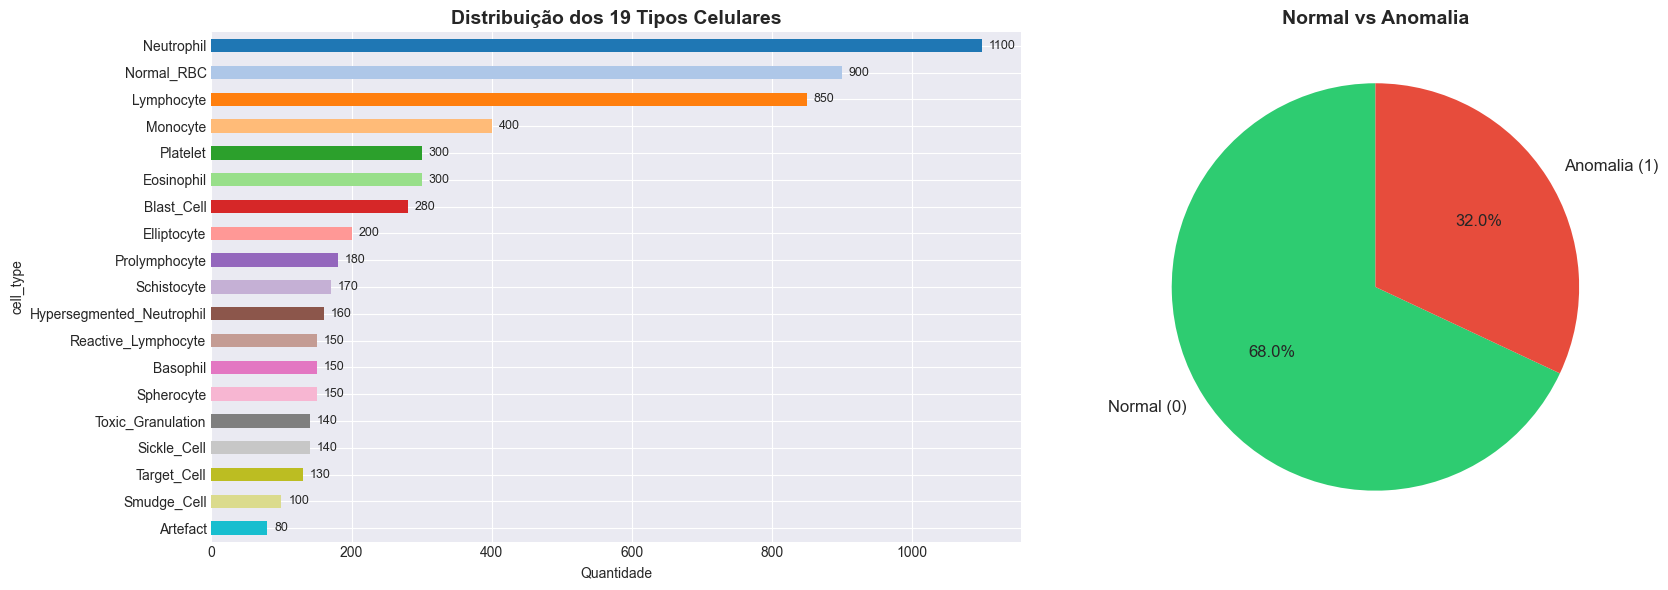


Normal:   4000 (68.0%)
Anomalia: 1880 (32.0%)


In [109]:
fig, axes = plt.subplots(1, 2, figsize=(18, 6))

# --- Distribuição dos 19 tipos celulares ---
cell_counts = df['cell_type'].value_counts()
colors_19 = sns.color_palette('tab20', n_colors=19)

cell_counts.plot(kind='barh', ax=axes[0], color=colors_19)
axes[0].set_title('Distribuição dos 19 Tipos Celulares', fontsize=14, fontweight='bold')
axes[0].set_xlabel('Quantidade')
axes[0].invert_yaxis()
for i, v in enumerate(cell_counts.values):
    axes[0].text(v + 10, i, str(v), va='center', fontsize=9)

# --- Normal vs Anomalia ---
anomaly_counts = df['anomaly_label'].value_counts()
labels_bin = ['Normal (0)', 'Anomalia (1)']
colors_bin = ['#2ecc71', '#e74c3c']
wedges, texts, autotexts = axes[1].pie(
    anomaly_counts.values, labels=labels_bin, autopct='%1.1f%%',
    colors=colors_bin, startangle=90, textprops={'fontsize': 12}
)
axes[1].set_title('Normal vs Anomalia', fontsize=14, fontweight='bold')

plt.tight_layout()
plt.savefig('01_distribuicao_celulas.png', dpi=150, bbox_inches='tight')
plt.show()

print(f"\nNormal:   {anomaly_counts[0]} ({anomaly_counts[0]/len(df)*100:.1f}%)")
print(f"Anomalia: {anomaly_counts[1]} ({anomaly_counts[1]/len(df)*100:.1f}%)")

### 3.3 Distribuição por Categoria de Doença

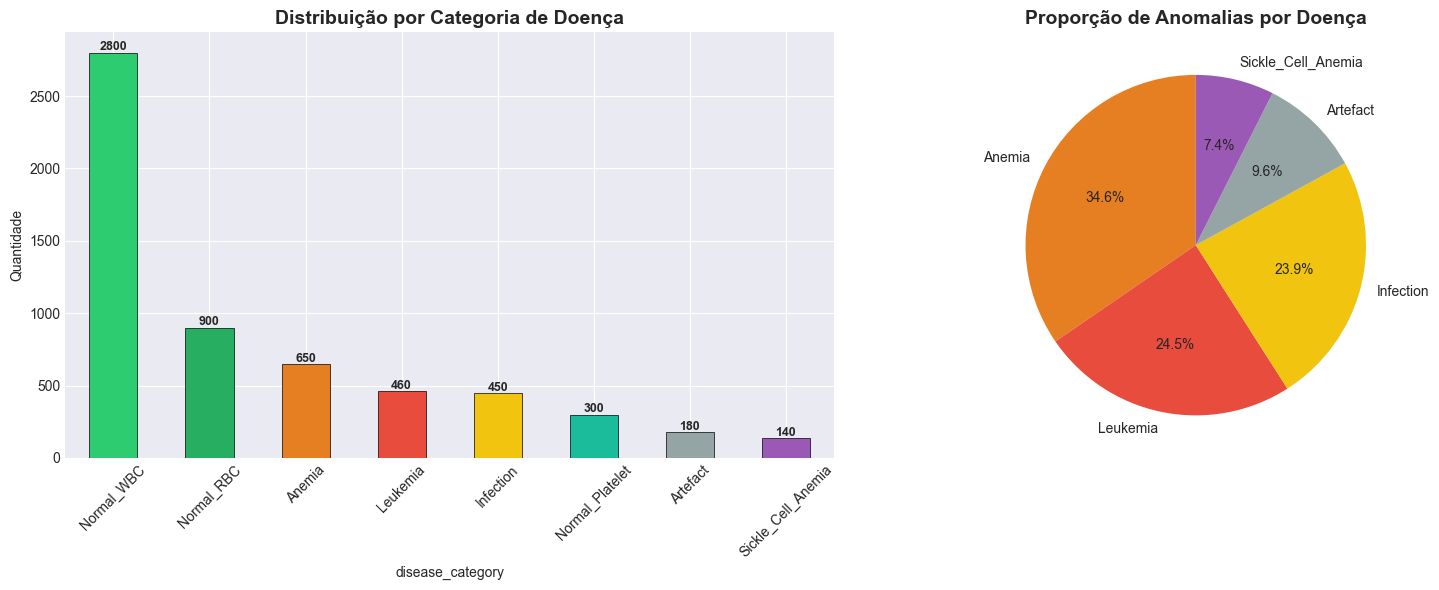

In [110]:
fig, axes = plt.subplots(1, 2, figsize=(16, 6))

# Contagem por categoria de doença
disease_counts = df['disease_category'].value_counts()
disease_colors = {
    'Normal_WBC': '#2ecc71', 'Normal_RBC': '#27ae60', 'Normal_Platelet': '#1abc9c',
    'Leukemia': '#e74c3c', 'Anemia': '#e67e22', 'Infection': '#f1c40f',
    'Sickle_Cell_Anemia': '#9b59b6', 'Artefact': '#95a5a6'
}
colors_disease = [disease_colors.get(d, '#bdc3c7') for d in disease_counts.index]

disease_counts.plot(kind='bar', ax=axes[0], color=colors_disease, edgecolor='black', linewidth=0.5)
axes[0].set_title('Distribuição por Categoria de Doença', fontsize=14, fontweight='bold')
axes[0].set_ylabel('Quantidade')
axes[0].tick_params(axis='x', rotation=45)
for i, v in enumerate(disease_counts.values):
    axes[0].text(i, v + 15, str(v), ha='center', fontsize=9, fontweight='bold')

# Proporção por doença dentro das anomalias
anomaly_only = df[df['anomaly_label'] == 1]
anom_disease = anomaly_only['disease_category'].value_counts()
anom_colors = [disease_colors.get(d, '#bdc3c7') for d in anom_disease.index]

axes[1].pie(anom_disease.values, labels=anom_disease.index, autopct='%1.1f%%',
            colors=anom_colors, startangle=90, textprops={'fontsize': 10})
axes[1].set_title('Proporção de Anomalias por Doença', fontsize=14, fontweight='bold')

plt.tight_layout()
plt.savefig('02_distribuicao_doencas.png', dpi=150, bbox_inches='tight')
plt.show()

### 3.4 Análise das Features Morfológicas

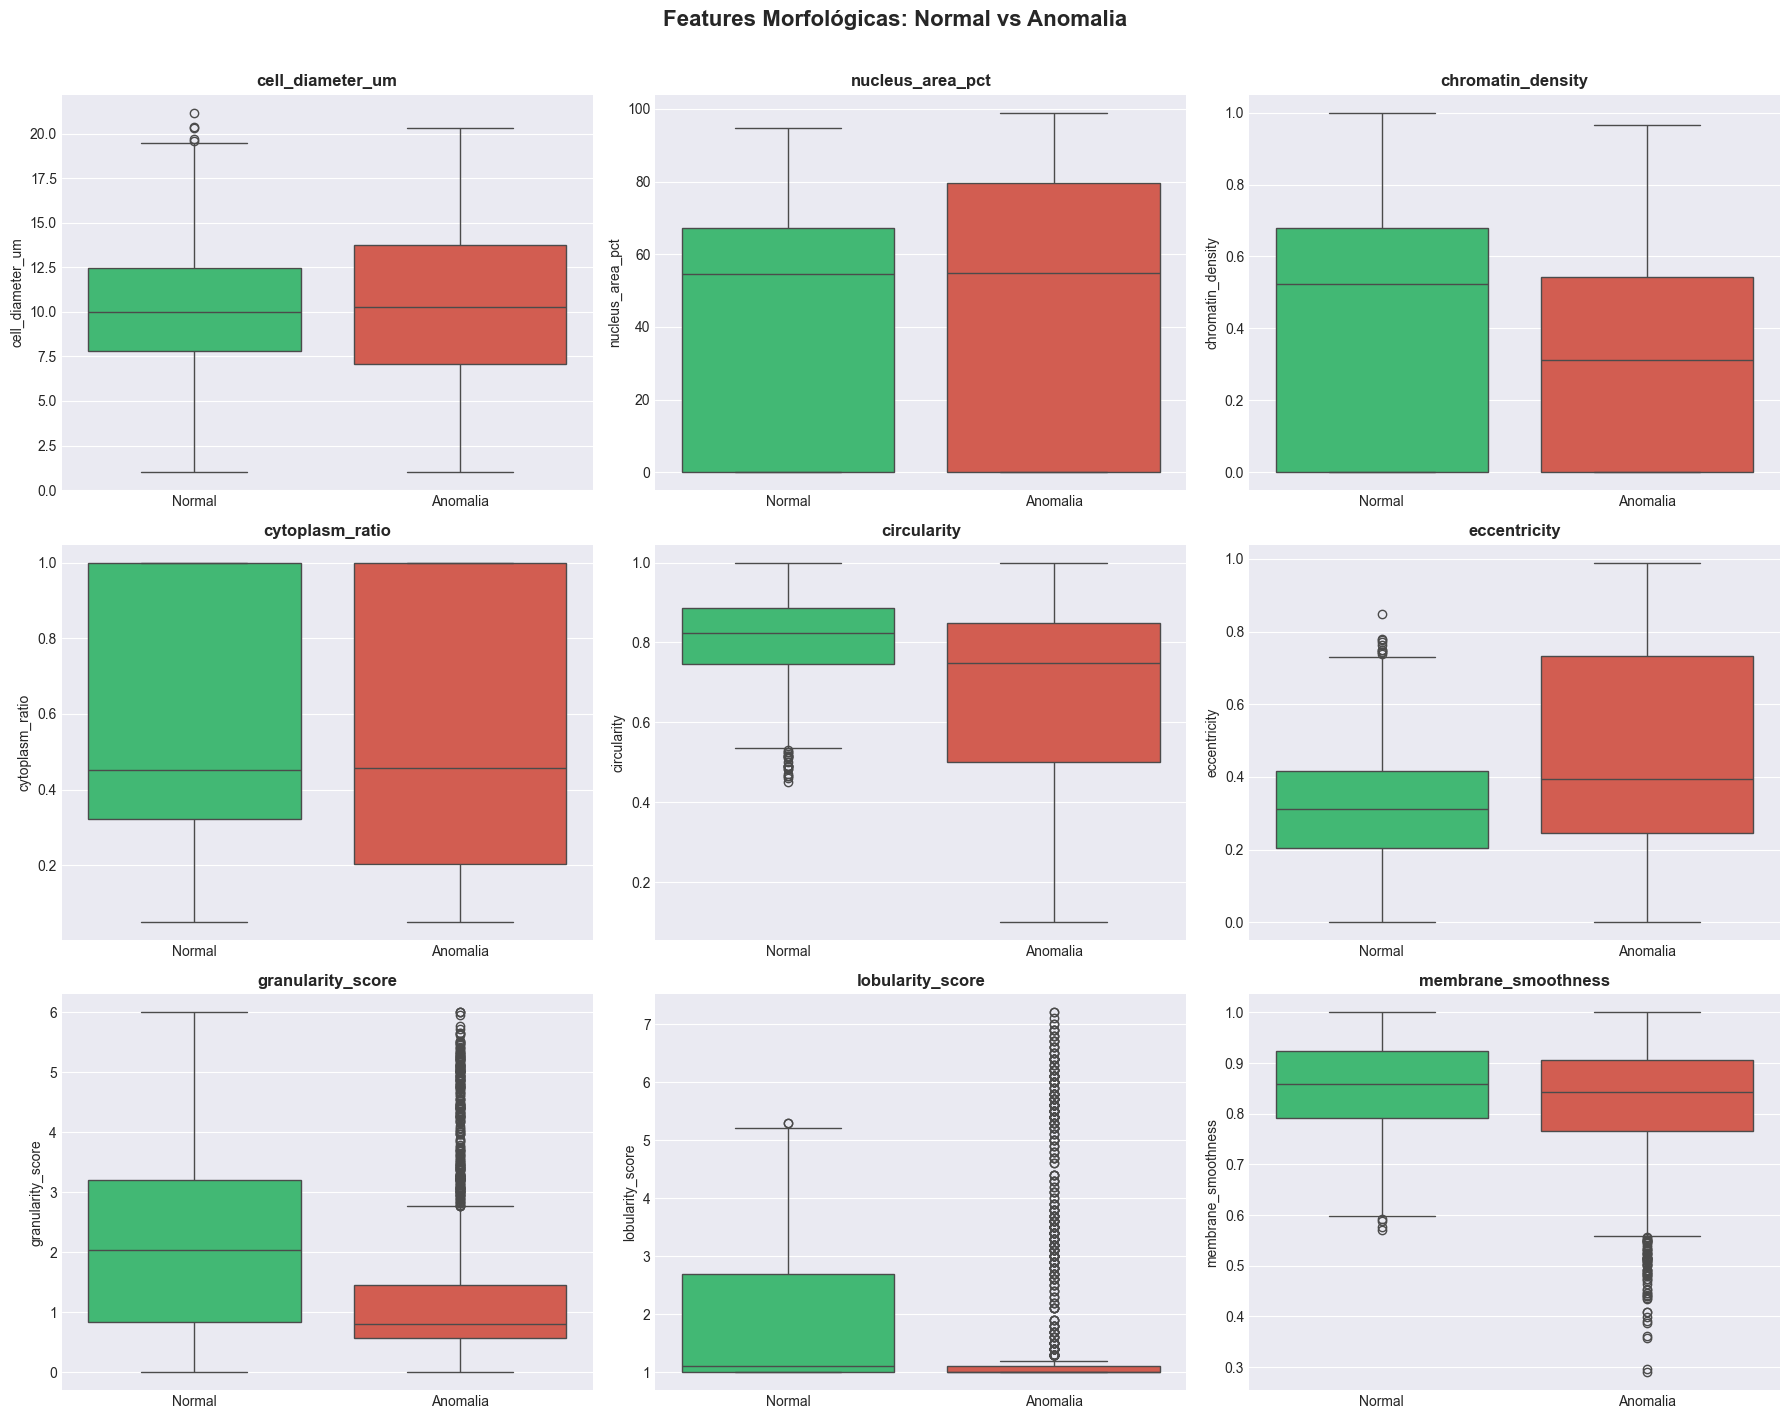

In [111]:
morph_features = [
    'cell_diameter_um', 'nucleus_area_pct', 'chromatin_density',
    'cytoplasm_ratio', 'circularity', 'eccentricity',
    'granularity_score', 'lobularity_score', 'membrane_smoothness'
]

fig, axes = plt.subplots(3, 3, figsize=(18, 14))
axes = axes.ravel()

for i, feat in enumerate(morph_features):
    sns.boxplot(data=df, x='anomaly_label', y=feat, ax=axes[i],
                palette=['#2ecc71', '#e74c3c'], hue='anomaly_label', legend=False)
    axes[i].set_title(feat, fontsize=12, fontweight='bold')
    axes[i].set_xticklabels(['Normal', 'Anomalia'])
    axes[i].set_xlabel('')

fig.suptitle('Features Morfológicas: Normal vs Anomalia', fontsize=16, fontweight='bold', y=1.01)
plt.tight_layout()
plt.savefig('03_features_morfologicas.png', dpi=150, bbox_inches='tight')
plt.show()

### 3.5 Distribuição de Features por Tipo Celular (Top diferenças)

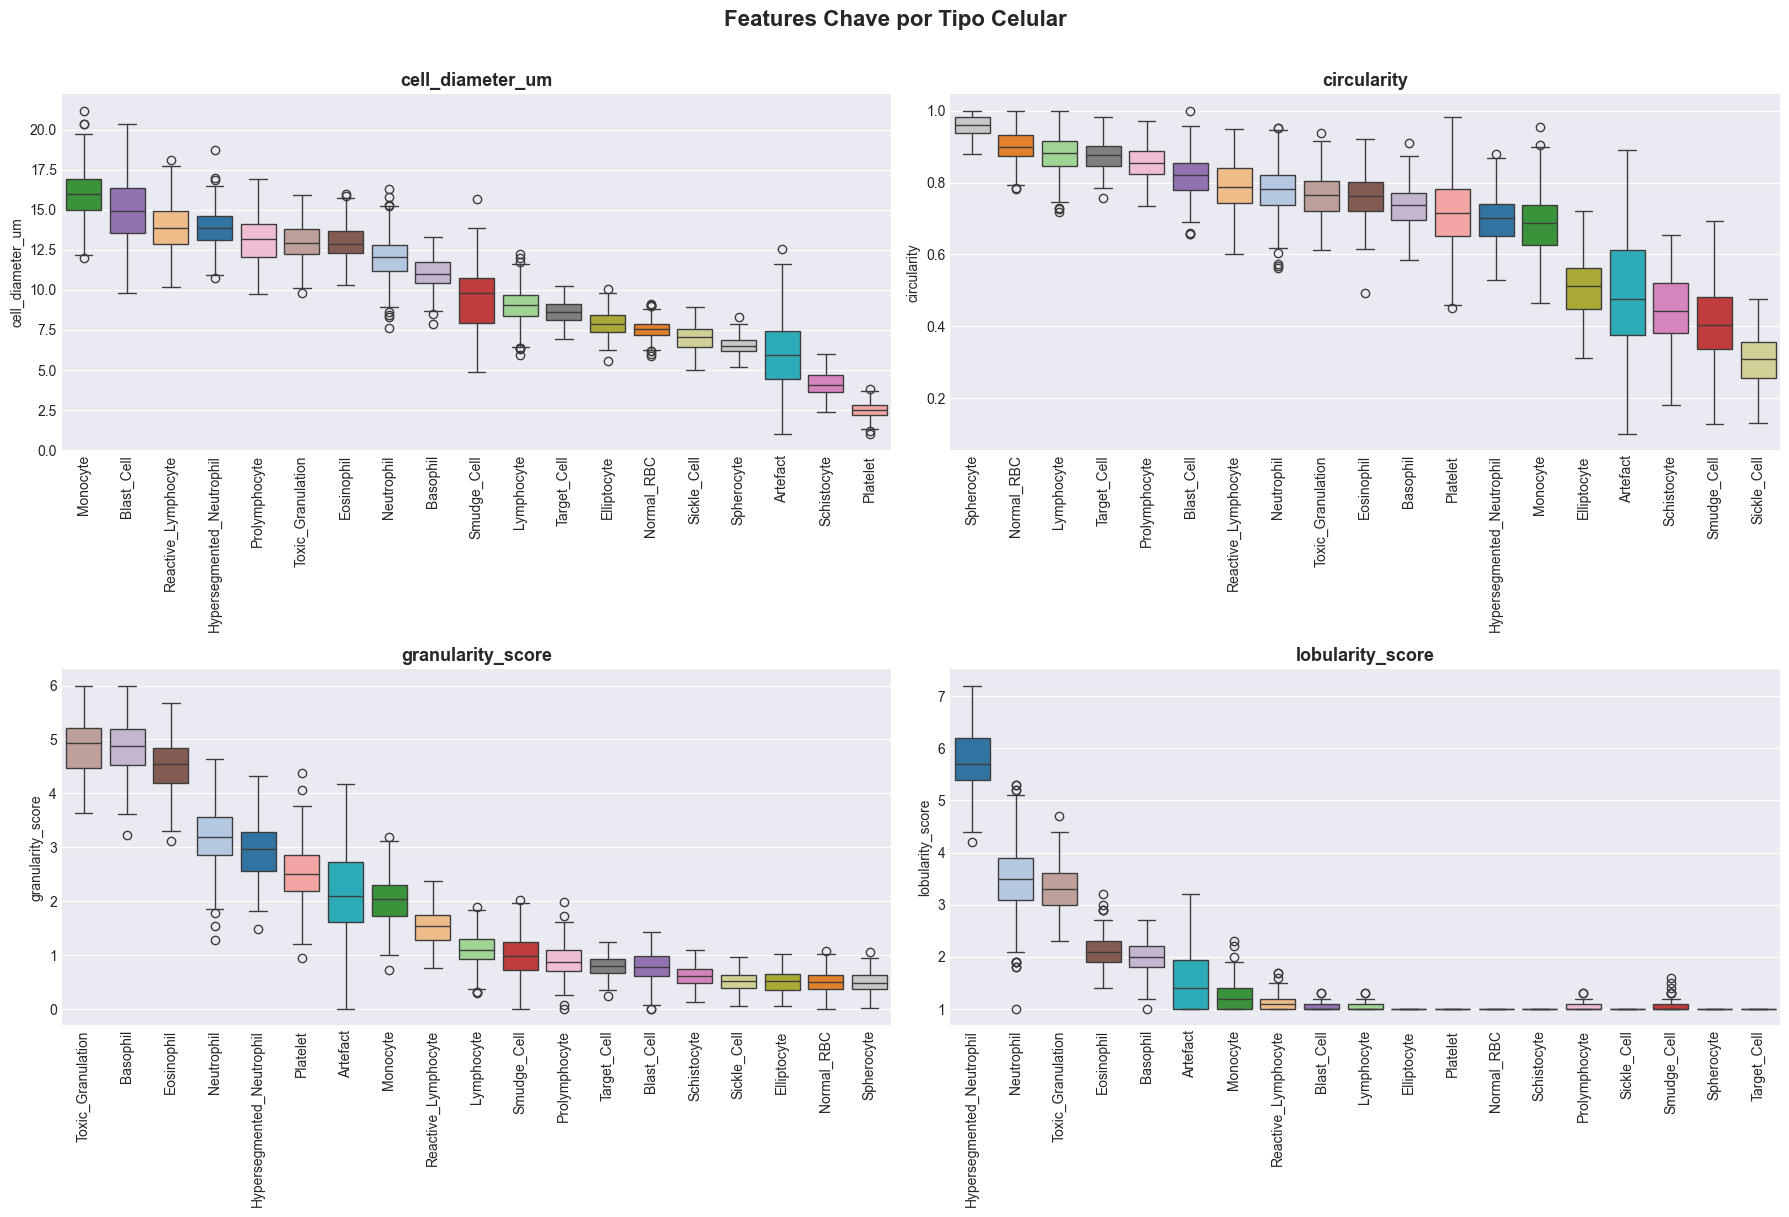

In [83]:
key_features = ['cell_diameter_um', 'circularity', 'granularity_score', 'lobularity_score']

fig, axes = plt.subplots(2, 2, figsize=(18, 12))
axes = axes.ravel()

for i, feat in enumerate(key_features):
    # Ordenar por mediana
    order = df.groupby('cell_type')[feat].median().sort_values(ascending=False).index
    sns.boxplot(data=df, x='cell_type', y=feat, order=order, ax=axes[i],
                palette='tab20', hue='cell_type', legend=False)
    axes[i].set_title(feat, fontsize=13, fontweight='bold')
    axes[i].tick_params(axis='x', rotation=90)
    axes[i].set_xlabel('')

fig.suptitle('Features Chave por Tipo Celular', fontsize=16, fontweight='bold', y=1.01)
plt.tight_layout()
plt.savefig('04_features_por_tipo.png', dpi=150, bbox_inches='tight')
plt.show()

### 3.6 Matriz de Correlação

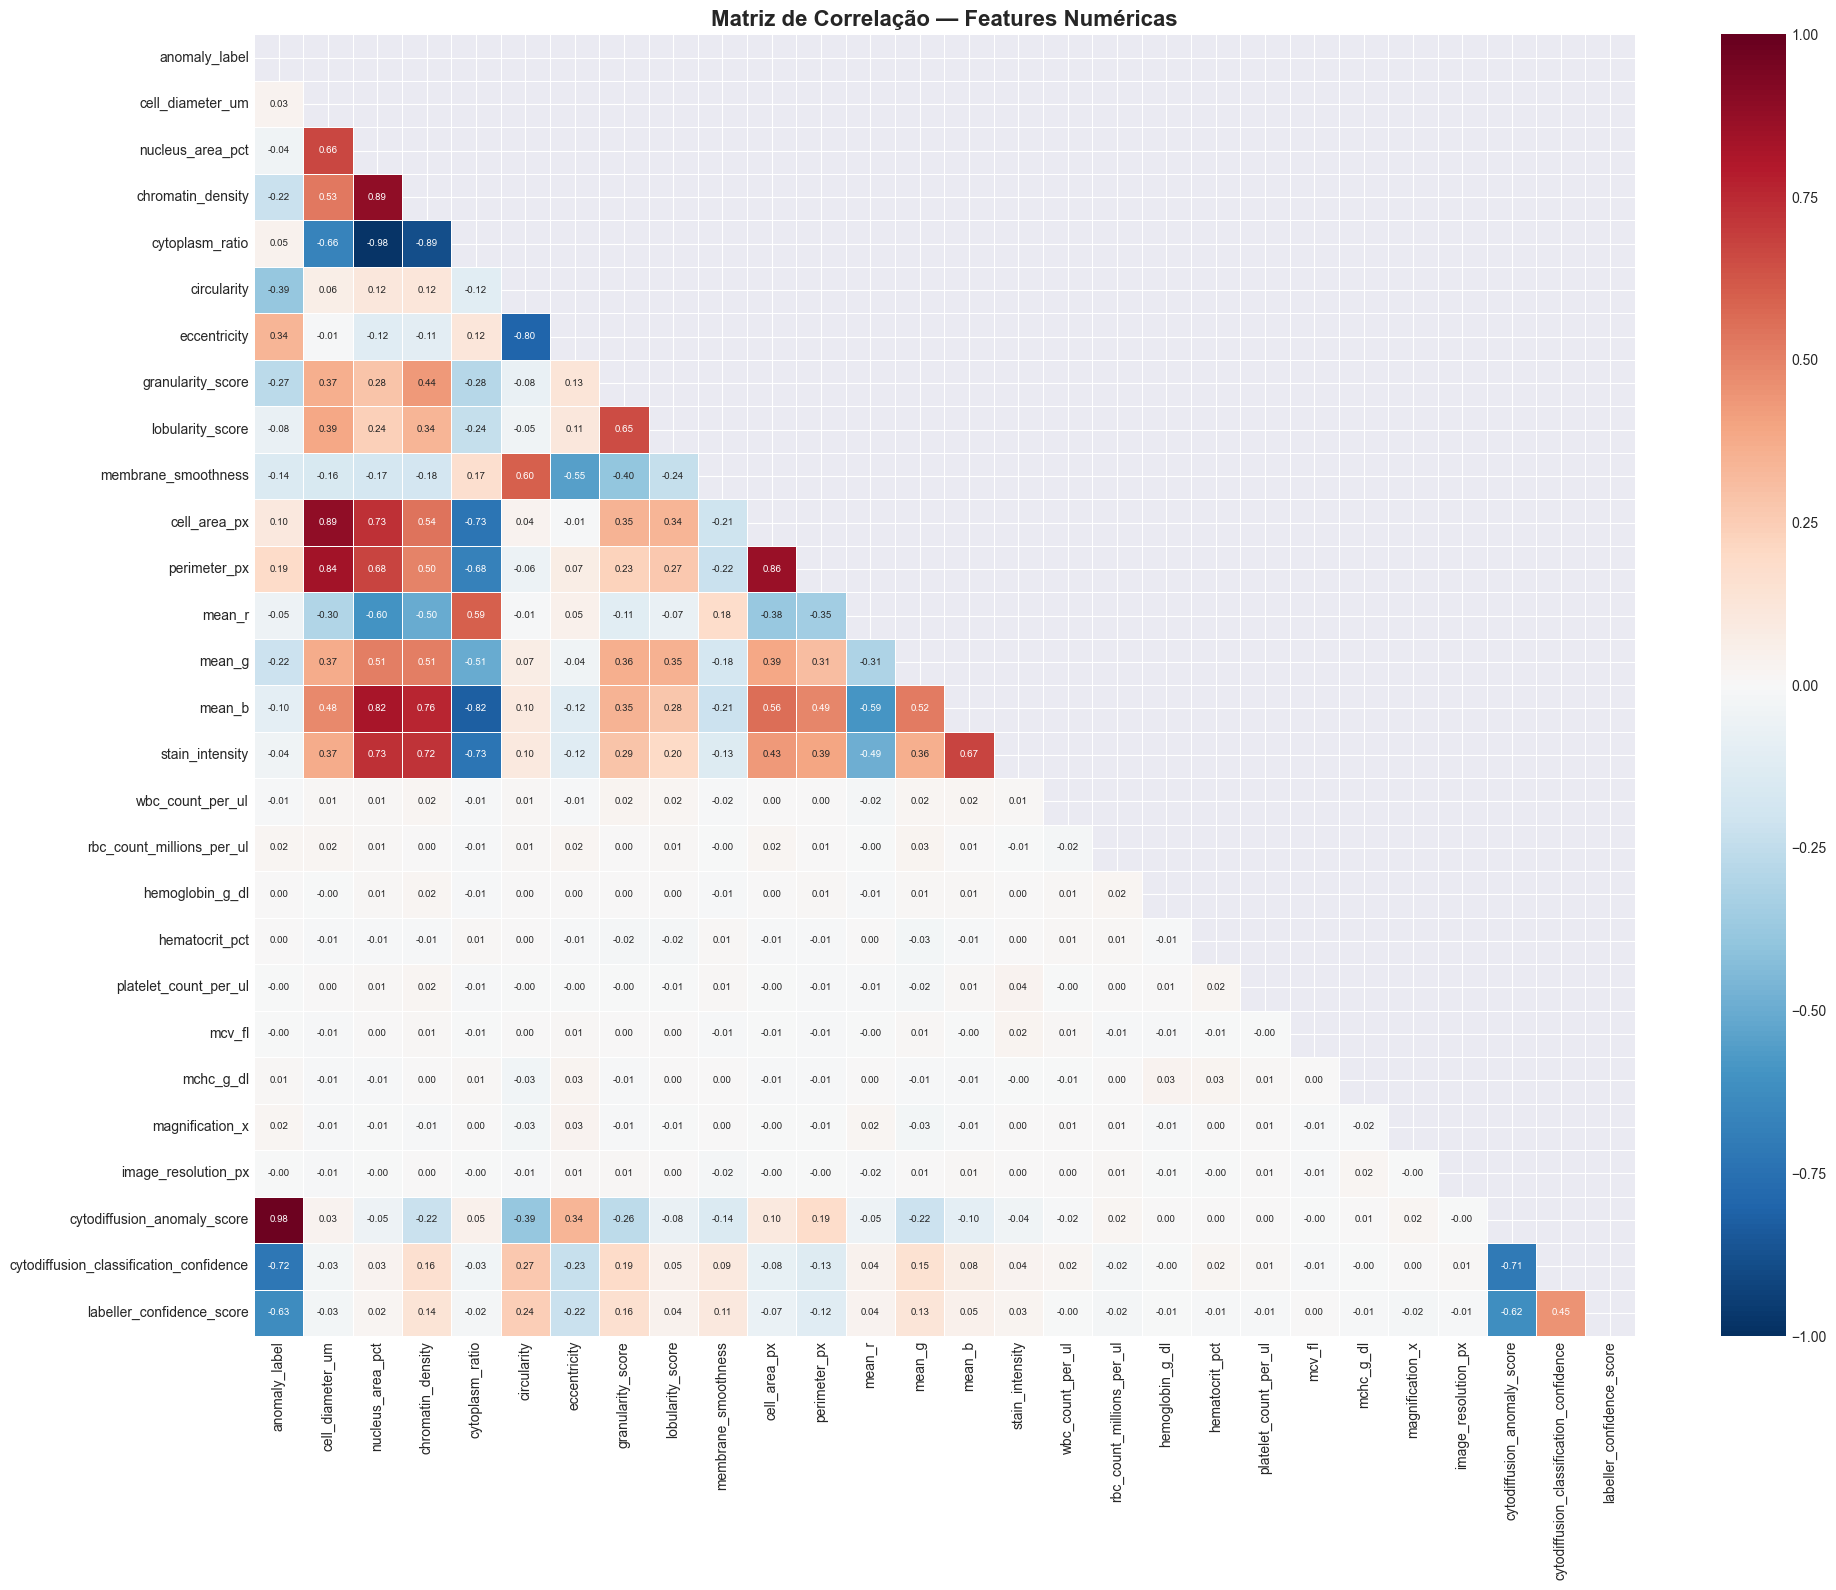

In [84]:
numeric_cols = df.select_dtypes(include=[np.number]).columns.tolist()
# Remover cell_id numérico se existir e anomaly_label para ver correlações com features
cols_corr = [c for c in numeric_cols if c not in ['cell_id']]

corr_matrix = df[cols_corr].corr()

fig, ax = plt.subplots(figsize=(20, 16))
mask = np.triu(np.ones_like(corr_matrix, dtype=bool))
sns.heatmap(corr_matrix, mask=mask, annot=True, fmt='.2f', cmap='RdBu_r',
            center=0, ax=ax, linewidths=0.5, annot_kws={'size': 7},
            vmin=-1, vmax=1)
ax.set_title('Matriz de Correlação — Features Numéricas', fontsize=16, fontweight='bold')
plt.tight_layout()
plt.savefig('05_correlacao.png', dpi=150, bbox_inches='tight')
plt.show()

### 3.7 Análise dos Scores do CytoDiffusion

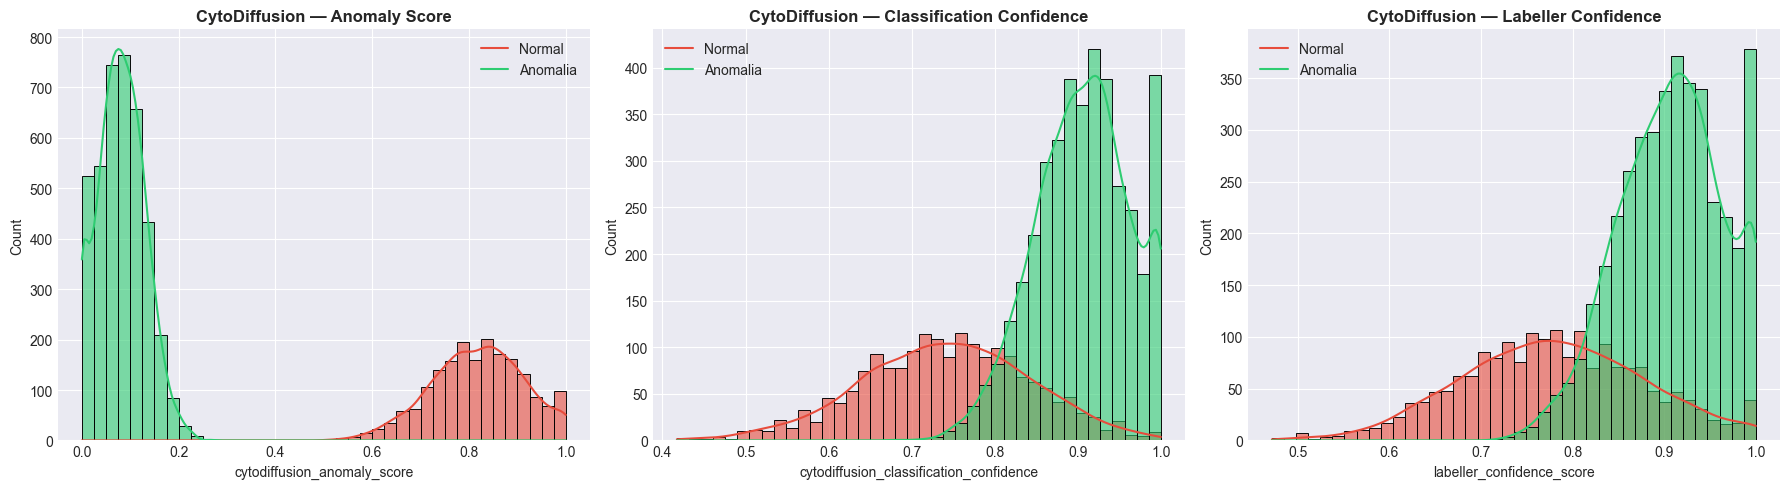

In [85]:
fig, axes = plt.subplots(1, 3, figsize=(18, 5))

score_cols = ['cytodiffusion_anomaly_score', 'cytodiffusion_classification_confidence', 'labeller_confidence_score']
titles = ['Anomaly Score', 'Classification Confidence', 'Labeller Confidence']

for i, (col, title) in enumerate(zip(score_cols, titles)):
    sns.histplot(data=df, x=col, hue='anomaly_label', kde=True, ax=axes[i],
                 palette=['#2ecc71', '#e74c3c'], alpha=0.6, bins=40)
    axes[i].set_title(f'CytoDiffusion — {title}', fontsize=12, fontweight='bold')
    axes[i].legend(['Normal', 'Anomalia'])

plt.tight_layout()
plt.savefig('06_cytodiffusion_scores.png', dpi=150, bbox_inches='tight')
plt.show()

### 3.8 Análise Demográfica (Idade e Sexo)

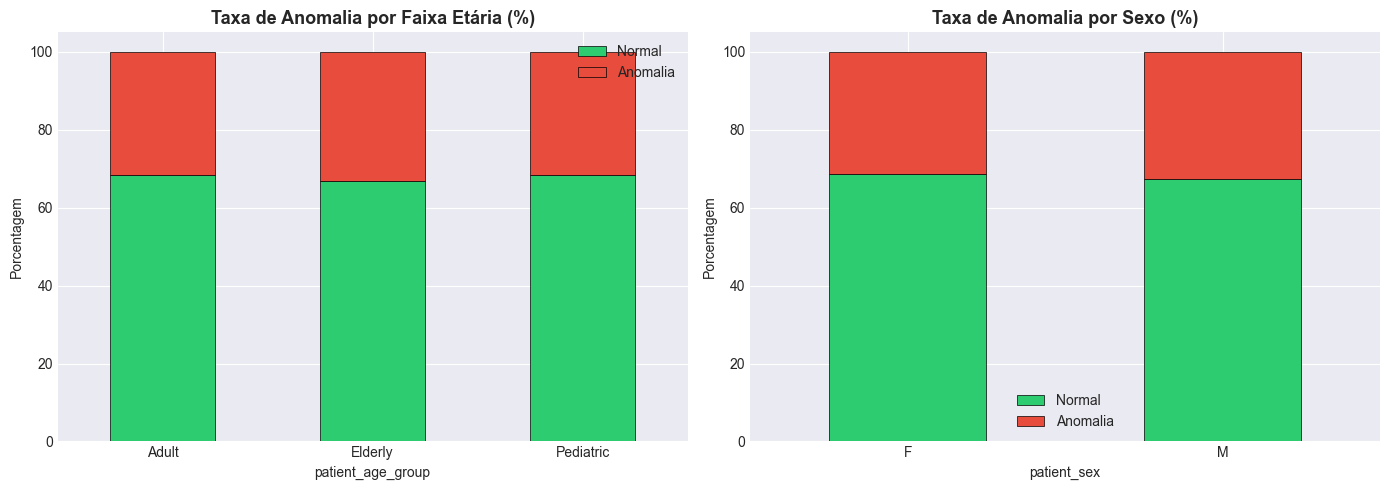

In [86]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Anomalias por faixa etária
age_anom = pd.crosstab(df['patient_age_group'], df['anomaly_label'], normalize='index') * 100
age_anom.plot(kind='bar', stacked=True, ax=axes[0], color=['#2ecc71', '#e74c3c'], edgecolor='black', linewidth=0.5)
axes[0].set_title('Taxa de Anomalia por Faixa Etária (%)', fontsize=13, fontweight='bold')
axes[0].set_ylabel('Porcentagem')
axes[0].legend(['Normal', 'Anomalia'])
axes[0].tick_params(axis='x', rotation=0)

# Anomalias por sexo
sex_anom = pd.crosstab(df['patient_sex'], df['anomaly_label'], normalize='index') * 100
sex_anom.plot(kind='bar', stacked=True, ax=axes[1], color=['#2ecc71', '#e74c3c'], edgecolor='black', linewidth=0.5)
axes[1].set_title('Taxa de Anomalia por Sexo (%)', fontsize=13, fontweight='bold')
axes[1].set_ylabel('Porcentagem')
axes[1].legend(['Normal', 'Anomalia'])
axes[1].tick_params(axis='x', rotation=0)

plt.tight_layout()
plt.savefig('07_demografia.png', dpi=150, bbox_inches='tight')
plt.show()

---

## 4. Pré-processamento

### 4.1 Preparação das Features

In [87]:
# Colunas categóricas e numéricas
cat_cols = df.select_dtypes(include='object').columns.tolist()
num_cols = df.select_dtypes(include=[np.number]).columns.tolist()

print('Colunas categóricas:', cat_cols)
print(f'\nColunas numéricas ({len(num_cols)}):', num_cols)

Colunas categóricas: ['cell_id', 'cell_type', 'disease_category', 'patient_age_group', 'patient_sex', 'dataset_source', 'staining_protocol', 'microscope_model']

Colunas numéricas (28): ['anomaly_label', 'cell_diameter_um', 'nucleus_area_pct', 'chromatin_density', 'cytoplasm_ratio', 'circularity', 'eccentricity', 'granularity_score', 'lobularity_score', 'membrane_smoothness', 'cell_area_px', 'perimeter_px', 'mean_r', 'mean_g', 'mean_b', 'stain_intensity', 'wbc_count_per_ul', 'rbc_count_millions_per_ul', 'hemoglobin_g_dl', 'hematocrit_pct', 'platelet_count_per_ul', 'mcv_fl', 'mchc_g_dl', 'magnification_x', 'image_resolution_px', 'cytodiffusion_anomaly_score', 'cytodiffusion_classification_confidence', 'labeller_confidence_score']


In [88]:
# Criar cópia para pré-processamento
df_processed = df.copy()

# Colunas alvo (targets)
target_binary = 'anomaly_label'         # 0 ou 1
target_multiclass = 'cell_type'         # 19 classes
target_disease = 'disease_category'     # 8 categorias

# Features que NÃO devem entrar no modelo (são targets, metadata ou causam data leakage)
exclude_from_features = ['cell_id', 'cell_type', 'anomaly_label', 'disease_category']

# Scores do CytoDiffusion — causam DATA LEAKAGE na classificação binária
# porque foram gerados a partir do próprio label de anomalia.
# Vamos separá-los para treinar dois cenários.
leakage_cols = ['cytodiffusion_anomaly_score', 'cytodiffusion_classification_confidence', 'labeller_confidence_score']

print('⚠️  ATENÇÃO — Data Leakage detectado!')
print(f'As colunas {leakage_cols} contêm informação direta do target.')
print('Serão REMOVIDAS das features para avaliação justa dos modelos.')
print('Um cenário separado com essas features será mostrado para comparação.\n')

# Encode de variáveis categóricas
cat_cols = df.select_dtypes(include='object').columns.tolist()
label_encoders = {}
for col in cat_cols:
    if col not in exclude_from_features:
        le = LabelEncoder()
        df_processed[col] = le.fit_transform(df_processed[col])
        label_encoders[col] = le
        print(f'{col}: {len(le.classes_)} categorias -> {list(le.classes_)}')

print(f'\nLabel encoders criados para {len(label_encoders)} colunas')

⚠️  ATENÇÃO — Data Leakage detectado!
As colunas ['cytodiffusion_anomaly_score', 'cytodiffusion_classification_confidence', 'labeller_confidence_score'] contêm informação direta do target.
Serão REMOVIDAS das features para avaliação justa dos modelos.
Um cenário separado com essas features será mostrado para comparação.

patient_age_group: 3 categorias -> ['Adult', 'Elderly', 'Pediatric']
patient_sex: 2 categorias -> ['F', 'M']
dataset_source: 3 categorias -> ['CytoData', 'PBC_Dataset', 'Raabin_WBC']
staining_protocol: 3 categorias -> ['Giemsa', 'May_Grunwald_Giemsa', 'Wright']
microscope_model: 3 categorias -> ['Leica_DM2000', 'Olympus_BX51', 'Zeiss_Axio']

Label encoders criados para 5 colunas


In [89]:
# Definir features (X) — SEM scores CytoDiffusion (sem leakage)
feature_cols = [c for c in df_processed.columns if c not in exclude_from_features + leakage_cols]
X = df_processed[feature_cols]

# Features COM scores CytoDiffusion (para comparação com benchmark)
feature_cols_all = [c for c in df_processed.columns if c not in exclude_from_features]
X_all = df_processed[feature_cols_all]

print(f'Features SEM leakage ({len(feature_cols)}):')
print(f'  {feature_cols}')
print(f'\nFeatures COM scores CytoDiffusion ({len(feature_cols_all)}):')
print(f'  Inclui também: {leakage_cols}')
print(f'\nShape de X (sem leakage): {X.shape}')

Features SEM leakage (29):
  ['cell_diameter_um', 'nucleus_area_pct', 'chromatin_density', 'cytoplasm_ratio', 'circularity', 'eccentricity', 'granularity_score', 'lobularity_score', 'membrane_smoothness', 'cell_area_px', 'perimeter_px', 'mean_r', 'mean_g', 'mean_b', 'stain_intensity', 'patient_age_group', 'patient_sex', 'wbc_count_per_ul', 'rbc_count_millions_per_ul', 'hemoglobin_g_dl', 'hematocrit_pct', 'platelet_count_per_ul', 'mcv_fl', 'mchc_g_dl', 'dataset_source', 'staining_protocol', 'microscope_model', 'magnification_x', 'image_resolution_px']

Features COM scores CytoDiffusion (32):
  Inclui também: ['cytodiffusion_anomaly_score', 'cytodiffusion_classification_confidence', 'labeller_confidence_score']

Shape de X (sem leakage): (5880, 29)


### 4.2 Escalonamento

In [90]:
scaler = StandardScaler()
X_scaled = pd.DataFrame(scaler.fit_transform(X), columns=X.columns, index=X.index)

# Também escalonar versão com todos os features (para cenário com CytoDiffusion scores)
scaler_all = StandardScaler()
X_scaled_all = pd.DataFrame(scaler_all.fit_transform(X_all), columns=X_all.columns, index=X_all.index)

print('Features escalonadas (StandardScaler):')
print(f'X sem leakage:  {X_scaled.shape[1]} features | Média ~0: {X_scaled.mean().mean():.6f}')
print(f'X com scores:   {X_scaled_all.shape[1]} features | Média ~0: {X_scaled_all.mean().mean():.6f}')

Features escalonadas (StandardScaler):
X sem leakage:  29 features | Média ~0: -0.000000
X com scores:   32 features | Média ~0: -0.000000


---

## 5. Modelagem — Classificação Binária (Normal vs Anomalia)

### 5.1 Split dos Dados

In [91]:
y_binary = df_processed[target_binary]

X_train, X_test, y_train, y_test = train_test_split(
    X_scaled, y_binary, test_size=0.2, random_state=RANDOM_STATE, stratify=y_binary
)

print(f'Treino: {X_train.shape[0]} amostras')
print(f'Teste:  {X_test.shape[0]} amostras')
print(f'\nDistribuição no treino:\n{y_train.value_counts()}')
print(f'\nDistribuição no teste:\n{y_test.value_counts()}')

Treino: 4704 amostras
Teste:  1176 amostras

Distribuição no treino:
anomaly_label
0    3200
1    1504
Name: count, dtype: int64

Distribuição no teste:
anomaly_label
0    800
1    376
Name: count, dtype: int64


### 5.2 Treinamento de Múltiplos Modelos

In [92]:
models = {
    'Logistic Regression': LogisticRegression(max_iter=1000, random_state=RANDOM_STATE),
    'Random Forest': RandomForestClassifier(n_estimators=200, random_state=RANDOM_STATE, n_jobs=-1),
    'Gradient Boosting': GradientBoostingClassifier(n_estimators=200, random_state=RANDOM_STATE),
    'KNN': KNeighborsClassifier(n_neighbors=7, n_jobs=-1),
    'SVM (RBF)': SVC(kernel='rbf', probability=True, random_state=RANDOM_STATE),
}

results_binary = {}

print('='*70)
print('CLASSIFICAÇÃO BINÁRIA — Normal vs Anomalia')
print('(SEM scores CytoDiffusion — avaliação justa)')
print('='*70)

for name, model in models.items():
    print(f'\nTreinando {name}...')
    model.fit(X_train, y_train)
    y_pred = model.predict(X_test)
    y_proba = model.predict_proba(X_test)[:, 1]
    
    acc = accuracy_score(y_test, y_pred)
    f1 = f1_score(y_test, y_pred)
    auc_score = roc_auc_score(y_test, y_proba)
    
    results_binary[name] = {
        'accuracy': acc, 'f1_score': f1, 'auc': auc_score,
        'y_pred': y_pred, 'y_proba': y_proba, 'model': model
    }
    
    print(f'  Accuracy: {acc:.4f} | F1-Score: {f1:.4f} | AUC: {auc_score:.4f}')

# --- Cenário COM scores CytoDiffusion (para comparação com benchmark) ---
print('\n\n' + '='*70)
print('CENÁRIO COM SCORES CYTODIFFUSION (inclui data leakage)')
print('='*70)

X_train_all, X_test_all, y_train_all, y_test_all = train_test_split(
    X_scaled_all, y_binary, test_size=0.2, random_state=RANDOM_STATE, stratify=y_binary
)

rf_with_scores = RandomForestClassifier(n_estimators=200, random_state=RANDOM_STATE, n_jobs=-1)
rf_with_scores.fit(X_train_all, y_train_all)
y_pred_ws = rf_with_scores.predict(X_test_all)
y_proba_ws = rf_with_scores.predict_proba(X_test_all)[:, 1]

auc_with_scores = roc_auc_score(y_test_all, y_proba_ws)
print(f'\n  Random Forest COM scores: AUC = {auc_with_scores:.4f} (esperado ~1.0 por leakage)')
print(f'  Isso confirma que os scores CytoDiffusion vazam a informação do target.')

print('\n' + '='*70)

CLASSIFICAÇÃO BINÁRIA — Normal vs Anomalia
(SEM scores CytoDiffusion — avaliação justa)

Treinando Logistic Regression...
  Accuracy: 0.8418 | F1-Score: 0.7199 | AUC: 0.8518

Treinando Random Forest...
  Accuracy: 0.9711 | F1-Score: 0.9530 | AUC: 0.9969

Treinando Gradient Boosting...
  Accuracy: 0.9753 | F1-Score: 0.9604 | AUC: 0.9950

Treinando KNN...
  Accuracy: 0.9022 | F1-Score: 0.8223 | AUC: 0.9316

Treinando SVM (RBF)...
  Accuracy: 0.9175 | F1-Score: 0.8524 | AUC: 0.9583


CENÁRIO COM SCORES CYTODIFFUSION (inclui data leakage)

  Random Forest COM scores: AUC = 1.0000 (esperado ~1.0 por leakage)
  Isso confirma que os scores CytoDiffusion vazam a informação do target.



### 5.3 Comparação dos Modelos

In [93]:
# Tabela comparativa
comparison = pd.DataFrame({
    name: {'Accuracy': r['accuracy'], 'F1-Score': r['f1_score'], 'AUC-ROC': r['auc']}
    for name, r in results_binary.items()
}).T.sort_values('AUC-ROC', ascending=False)

print('Comparação dos Modelos — Classificação Binária:\n')
print(comparison.round(4).to_string())

Comparação dos Modelos — Classificação Binária:

                     Accuracy  F1-Score  AUC-ROC
Random Forest          0.9711    0.9530   0.9969
Gradient Boosting      0.9753    0.9604   0.9950
SVM (RBF)              0.9175    0.8524   0.9583
KNN                    0.9022    0.8223   0.9316
Logistic Regression    0.8418    0.7199   0.8518


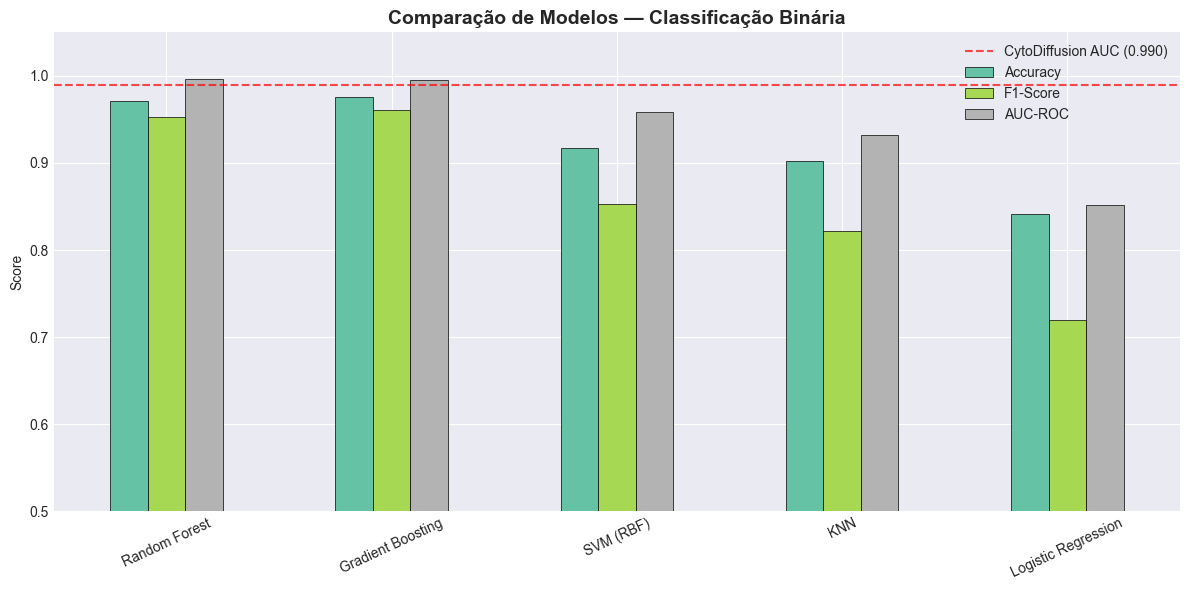

In [94]:
# Gráfico comparativo
fig, ax = plt.subplots(figsize=(12, 6))
comparison.plot(kind='bar', ax=ax, colormap='Set2', edgecolor='black', linewidth=0.5)
ax.set_title('Comparação de Modelos — Classificação Binária', fontsize=14, fontweight='bold')
ax.set_ylabel('Score')
ax.set_ylim(0.5, 1.05)
ax.tick_params(axis='x', rotation=25)
ax.legend(loc='lower right')
ax.axhline(y=0.990, color='red', linestyle='--', alpha=0.7, label='CytoDiffusion AUC (0.990)')
ax.legend()

plt.tight_layout()
plt.savefig('08_comparacao_modelos_binario.png', dpi=150, bbox_inches='tight')
plt.show()

### 5.4 Curvas ROC

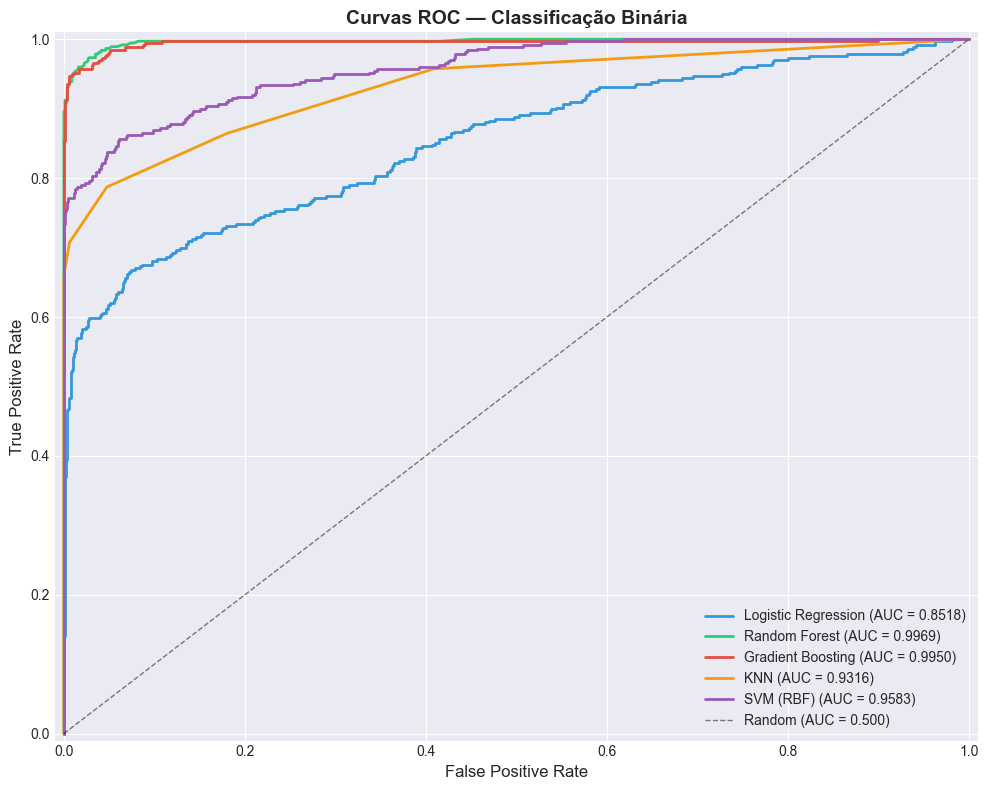

In [95]:
fig, ax = plt.subplots(figsize=(10, 8))
colors_roc = ['#3498db', '#2ecc71', '#e74c3c', '#f39c12', '#9b59b6']

for i, (name, r) in enumerate(results_binary.items()):
    fpr, tpr, _ = roc_curve(y_test, r['y_proba'])
    roc_auc_val = auc(fpr, tpr)
    ax.plot(fpr, tpr, color=colors_roc[i], lw=2,
            label=f'{name} (AUC = {roc_auc_val:.4f})')

ax.plot([0, 1], [0, 1], 'k--', lw=1, alpha=0.5, label='Random (AUC = 0.500)')
ax.set_xlabel('False Positive Rate', fontsize=12)
ax.set_ylabel('True Positive Rate', fontsize=12)
ax.set_title('Curvas ROC — Classificação Binária', fontsize=14, fontweight='bold')
ax.legend(loc='lower right', fontsize=10)
ax.set_xlim([-0.01, 1.01])
ax.set_ylim([-0.01, 1.01])

plt.tight_layout()
plt.savefig('09_curvas_roc.png', dpi=150, bbox_inches='tight')
plt.show()

### 5.5 Matriz de Confusão (Melhor Modelo)

Melhor modelo: Random Forest (AUC = 0.9969)

CLASSIFICATION REPORT
              precision    recall  f1-score   support

      Normal       0.96      1.00      0.98       800
    Anomalia       0.99      0.92      0.95       376

    accuracy                           0.97      1176
   macro avg       0.98      0.96      0.97      1176
weighted avg       0.97      0.97      0.97      1176



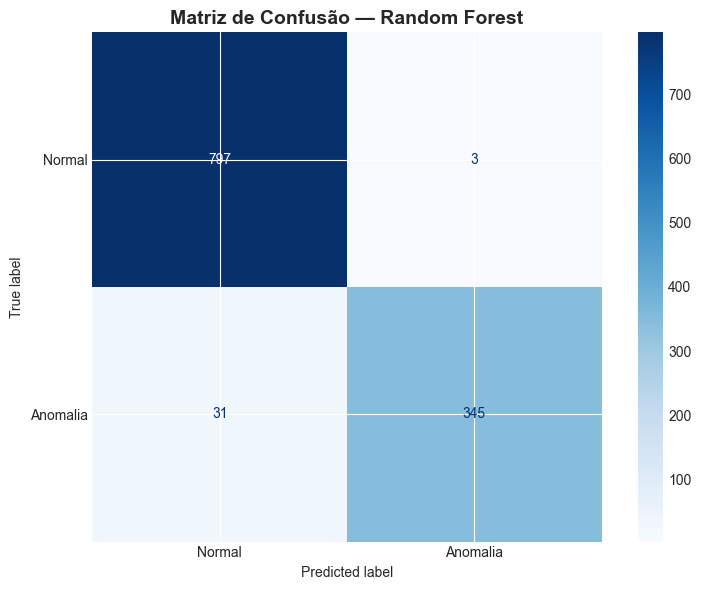

In [96]:
# Pegar o melhor modelo baseado em AUC
best_name = comparison.index[0]
best_result = results_binary[best_name]

print(f'Melhor modelo: {best_name} (AUC = {best_result["auc"]:.4f})')
print('\n' + '='*60)
print('CLASSIFICATION REPORT')
print('='*60)
print(classification_report(y_test, best_result['y_pred'], target_names=['Normal', 'Anomalia']))

fig, ax = plt.subplots(figsize=(8, 6))
ConfusionMatrixDisplay.from_predictions(
    y_test, best_result['y_pred'],
    display_labels=['Normal', 'Anomalia'],
    cmap='Blues', ax=ax
)
ax.set_title(f'Matriz de Confusão — {best_name}', fontsize=14, fontweight='bold')

plt.tight_layout()
plt.savefig('10_confusion_matrix_binario.png', dpi=150, bbox_inches='tight')
plt.show()

### 5.6 Cross-Validation (Melhor Modelo)

In [97]:
cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=RANDOM_STATE)

cv_scores = cross_val_score(best_result['model'], X_scaled, y_binary, cv=cv, scoring='roc_auc', n_jobs=-1)

print(f'Cross-Validation (5-Fold) — {best_name}')
print(f'AUC por fold: {cv_scores.round(4)}')
print(f'AUC médio:    {cv_scores.mean():.4f} (+/- {cv_scores.std():.4f})')

Cross-Validation (5-Fold) — Random Forest
AUC por fold: [0.9939 0.992  0.9958 0.9882 0.9933]
AUC médio:    0.9927 (+/- 0.0025)


---

## 6. Modelagem — Classificação Multi-Classe (19 Tipos Celulares)

### 6.1 Preparação e Treinamento

In [98]:
# Encode do target multi-classe
le_cell = LabelEncoder()
y_multi = le_cell.fit_transform(df_processed[target_multiclass])

X_train_m, X_test_m, y_train_m, y_test_m = train_test_split(
    X_scaled, y_multi, test_size=0.2, random_state=RANDOM_STATE, stratify=y_multi
)

print(f'Classes ({len(le_cell.classes_)}): {list(le_cell.classes_)}')
print(f'Features utilizadas: {len(feature_cols)} (sem scores CytoDiffusion)')
print(f'\nTreino: {X_train_m.shape[0]} | Teste: {X_test_m.shape[0]}')

Classes (19): ['Artefact', 'Basophil', 'Blast_Cell', 'Elliptocyte', 'Eosinophil', 'Hypersegmented_Neutrophil', 'Lymphocyte', 'Monocyte', 'Neutrophil', 'Normal_RBC', 'Platelet', 'Prolymphocyte', 'Reactive_Lymphocyte', 'Schistocyte', 'Sickle_Cell', 'Smudge_Cell', 'Spherocyte', 'Target_Cell', 'Toxic_Granulation']
Features utilizadas: 29 (sem scores CytoDiffusion)

Treino: 4704 | Teste: 1176


In [99]:
# Treinar Random Forest e Gradient Boosting (melhores para multi-classe)
models_multi = {
    'Random Forest': RandomForestClassifier(n_estimators=300, random_state=RANDOM_STATE, n_jobs=-1),
    'Gradient Boosting': GradientBoostingClassifier(n_estimators=200, random_state=RANDOM_STATE),
}

results_multi = {}

print('='*70)
print('CLASSIFICAÇÃO MULTI-CLASSE — 19 Tipos Celulares')
print('='*70)

for name, model in models_multi.items():
    print(f'\nTreinando {name}...')
    model.fit(X_train_m, y_train_m)
    y_pred_m = model.predict(X_test_m)
    
    acc = accuracy_score(y_test_m, y_pred_m)
    f1 = f1_score(y_test_m, y_pred_m, average='weighted')
    
    results_multi[name] = {'accuracy': acc, 'f1_weighted': f1, 'y_pred': y_pred_m, 'model': model}
    print(f'  Accuracy: {acc:.4f} | F1-Score (weighted): {f1:.4f}')

print('\n' + '='*70)

CLASSIFICAÇÃO MULTI-CLASSE — 19 Tipos Celulares

Treinando Random Forest...
  Accuracy: 0.9515 | F1-Score (weighted): 0.9490

Treinando Gradient Boosting...
  Accuracy: 0.9507 | F1-Score (weighted): 0.9497



### 6.2 Classification Report e Confusion Matrix (Multi-Classe)

In [100]:
# Melhor modelo multi-classe
best_multi_name = max(results_multi, key=lambda k: results_multi[k]['f1_weighted'])
best_multi = results_multi[best_multi_name]

print(f'Melhor modelo multi-classe: {best_multi_name}')
print('\n' + '='*70)
print('CLASSIFICATION REPORT — 19 TIPOS CELULARES')
print('='*70)
print(classification_report(y_test_m, best_multi['y_pred'], target_names=le_cell.classes_))

Melhor modelo multi-classe: Gradient Boosting

CLASSIFICATION REPORT — 19 TIPOS CELULARES


                           precision    recall  f1-score   support

                 Artefact       1.00      0.94      0.97        16
                 Basophil       0.97      1.00      0.98        30
               Blast_Cell       0.78      0.84      0.81        56
              Elliptocyte       0.95      0.95      0.95        40
               Eosinophil       0.95      0.97      0.96        60
Hypersegmented_Neutrophil       1.00      1.00      1.00        32
               Lymphocyte       1.00      1.00      1.00       170
                 Monocyte       0.99      0.99      0.99        80
               Neutrophil       0.99      0.98      0.98       220
               Normal_RBC       0.93      0.98      0.95       180
                 Platelet       1.00      1.00      1.00        60
            Prolymphocyte       0.71      0.61      0.66        36
      Reactive_Lymphocyte       0.97      0.97      0.97        30
              Schistocyte       0.97      1.00      0.99     

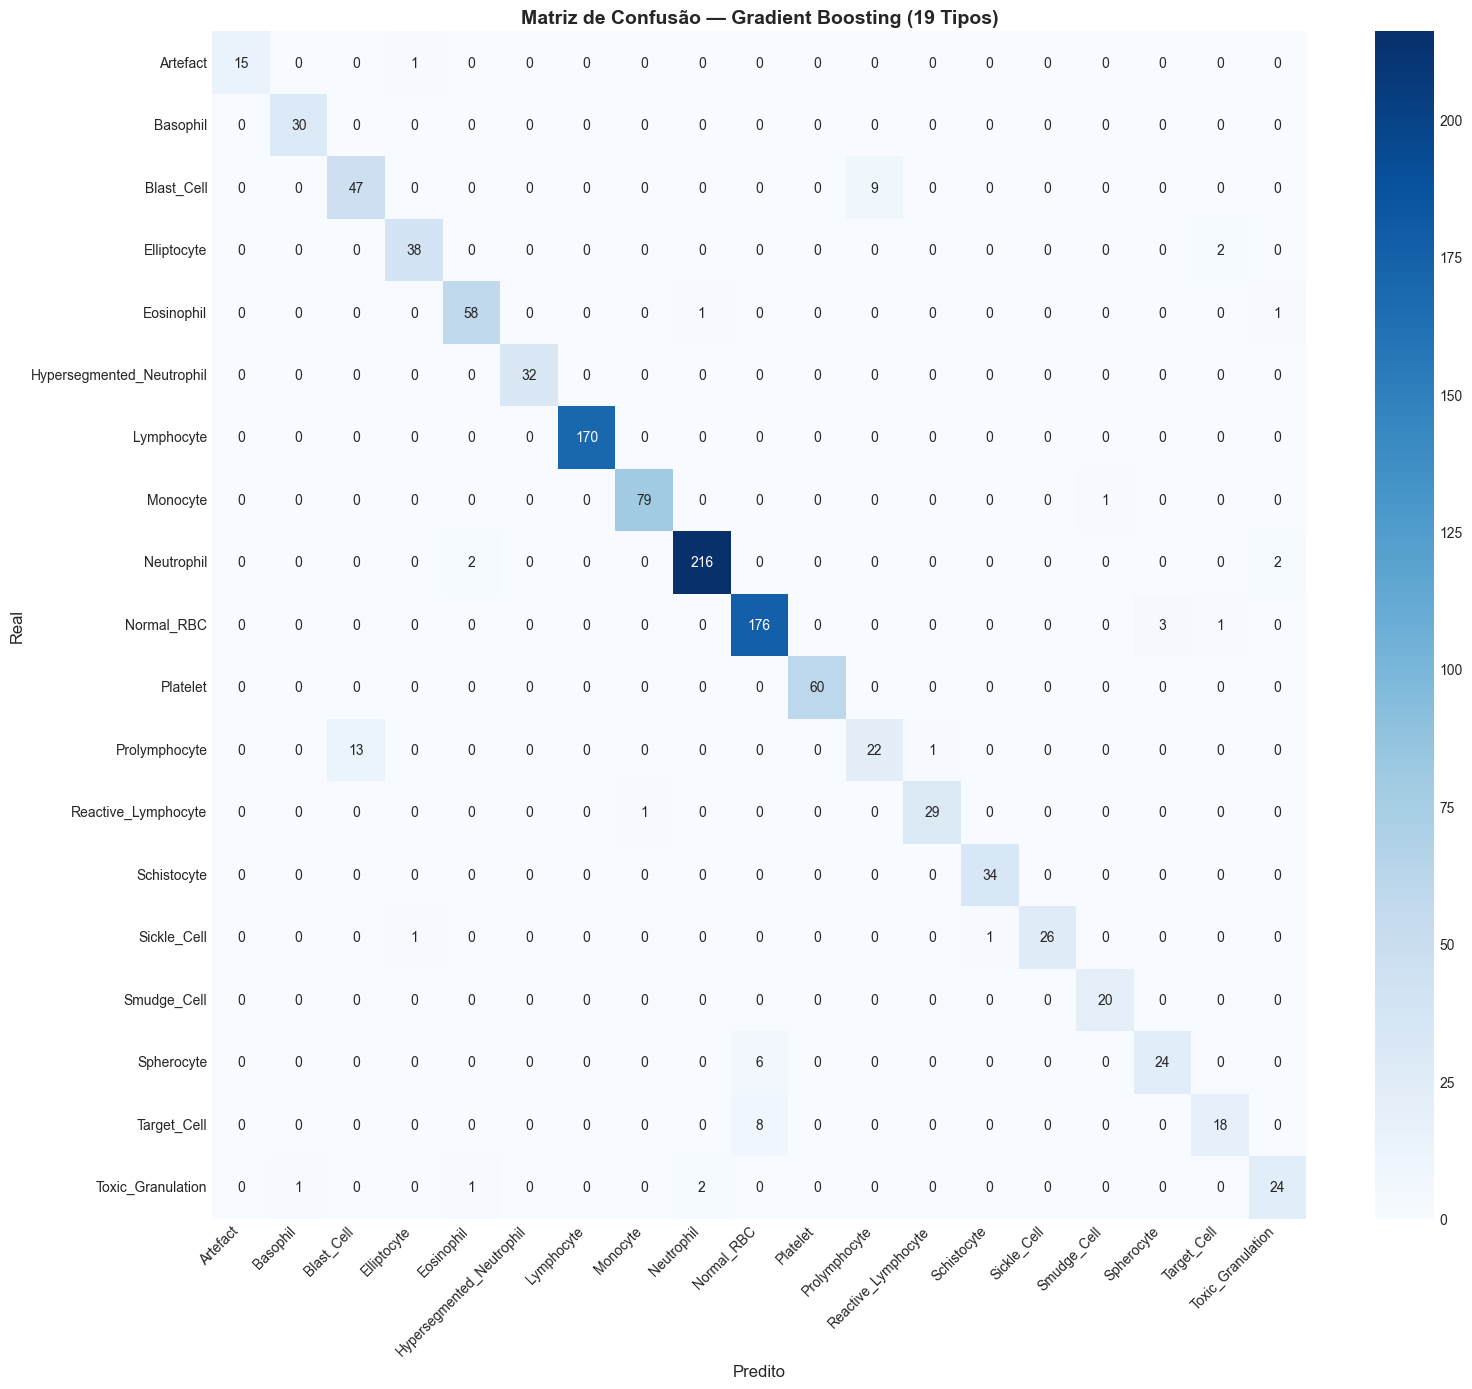

In [101]:
# Confusion Matrix multi-classe
fig, ax = plt.subplots(figsize=(16, 14))
cm = confusion_matrix(y_test_m, best_multi['y_pred'])
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=le_cell.classes_, yticklabels=le_cell.classes_, ax=ax)
ax.set_xlabel('Predito', fontsize=12)
ax.set_ylabel('Real', fontsize=12)
ax.set_title(f'Matriz de Confusão — {best_multi_name} (19 Tipos)', fontsize=14, fontweight='bold')
plt.xticks(rotation=45, ha='right')
plt.yticks(rotation=0)

plt.tight_layout()
plt.savefig('11_confusion_matrix_multiclass.png', dpi=150, bbox_inches='tight')
plt.show()

---

## 7. Modelagem — Predição por Categoria de Doença

### 7.1 Treinamento

In [112]:
le_disease = LabelEncoder()
y_disease = le_disease.fit_transform(df_processed[target_disease])

X_train_d, X_test_d, y_train_d, y_test_d = train_test_split(
    X_scaled, y_disease, test_size=0.2, random_state=RANDOM_STATE, stratify=y_disease
)

print(f'Categorias de doença: {list(le_disease.classes_)}')
print(f'Features utilizadas: {len(feature_cols)} (sem scores CytoDiffusion)')
print(f'Treino: {X_train_d.shape[0]} | Teste: {X_test_d.shape[0]}')

# Random Forest para doença
rf_disease = RandomForestClassifier(n_estimators=300, random_state=RANDOM_STATE, n_jobs=-1)
rf_disease.fit(X_train_d, y_train_d)
y_pred_d = rf_disease.predict(X_test_d)

acc_d = accuracy_score(y_test_d, y_pred_d)
f1_d = f1_score(y_test_d, y_pred_d, average='weighted')

print(f'\nRandom Forest — Predição de Doença:')
print(f'  Accuracy: {acc_d:.4f} | F1 (weighted): {f1_d:.4f}')

Categorias de doença: ['Anemia', 'Artefact', 'Infection', 'Leukemia', 'Normal_Platelet', 'Normal_RBC', 'Normal_WBC', 'Sickle_Cell_Anemia']
Features utilizadas: 29 (sem scores CytoDiffusion)
Treino: 4704 | Teste: 1176

Random Forest — Predição de Doença:
  Accuracy: 0.9498 | F1 (weighted): 0.9473


CLASSIFICATION REPORT — Categorias de Doença
                    precision    recall  f1-score   support

            Anemia       0.94      0.84      0.89       130
          Artefact       1.00      1.00      1.00        36
         Infection       0.98      0.67      0.79        90
          Leukemia       0.99      1.00      0.99        92
   Normal_Platelet       1.00      1.00      1.00        60
        Normal_RBC       0.89      0.98      0.93       180
        Normal_WBC       0.95      1.00      0.97       560
Sickle_Cell_Anemia       1.00      0.89      0.94        28

          accuracy                           0.95      1176
         macro avg       0.97      0.92      0.94      1176
      weighted avg       0.95      0.95      0.95      1176



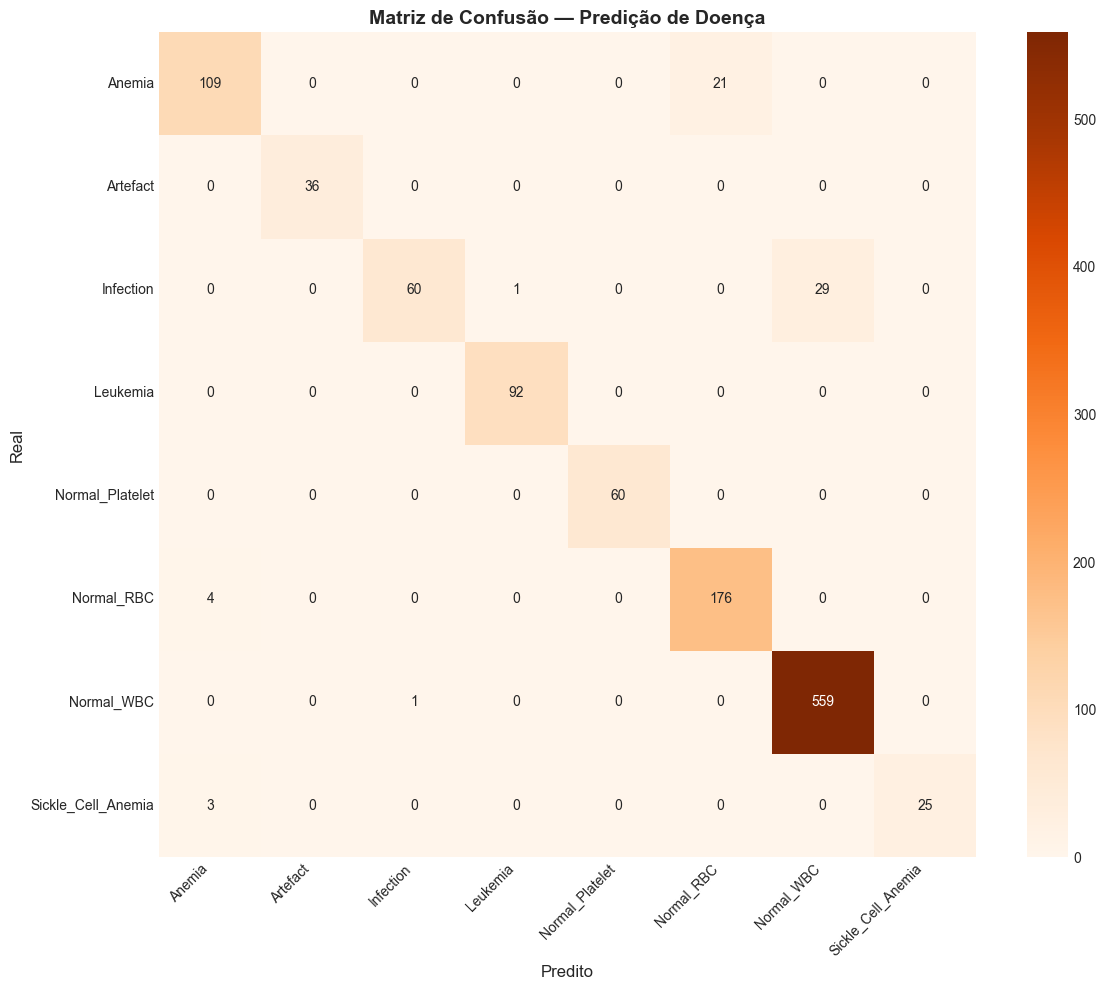

In [113]:
print('CLASSIFICATION REPORT — Categorias de Doença')
print('='*60)
print(classification_report(y_test_d, y_pred_d, target_names=le_disease.classes_))

fig, ax = plt.subplots(figsize=(12, 10))
cm_d = confusion_matrix(y_test_d, y_pred_d)
sns.heatmap(cm_d, annot=True, fmt='d', cmap='Oranges',
            xticklabels=le_disease.classes_, yticklabels=le_disease.classes_, ax=ax)
ax.set_xlabel('Predito', fontsize=12)
ax.set_ylabel('Real', fontsize=12)
ax.set_title('Matriz de Confusão — Predição de Doença', fontsize=14, fontweight='bold')
plt.xticks(rotation=45, ha='right')
plt.yticks(rotation=0)

plt.tight_layout()
plt.savefig('12_confusion_matrix_doenca.png', dpi=150, bbox_inches='tight')
plt.show()

---

## 8. Feature Importance

### 8.1 Importância das Features (Random Forest — Binário)

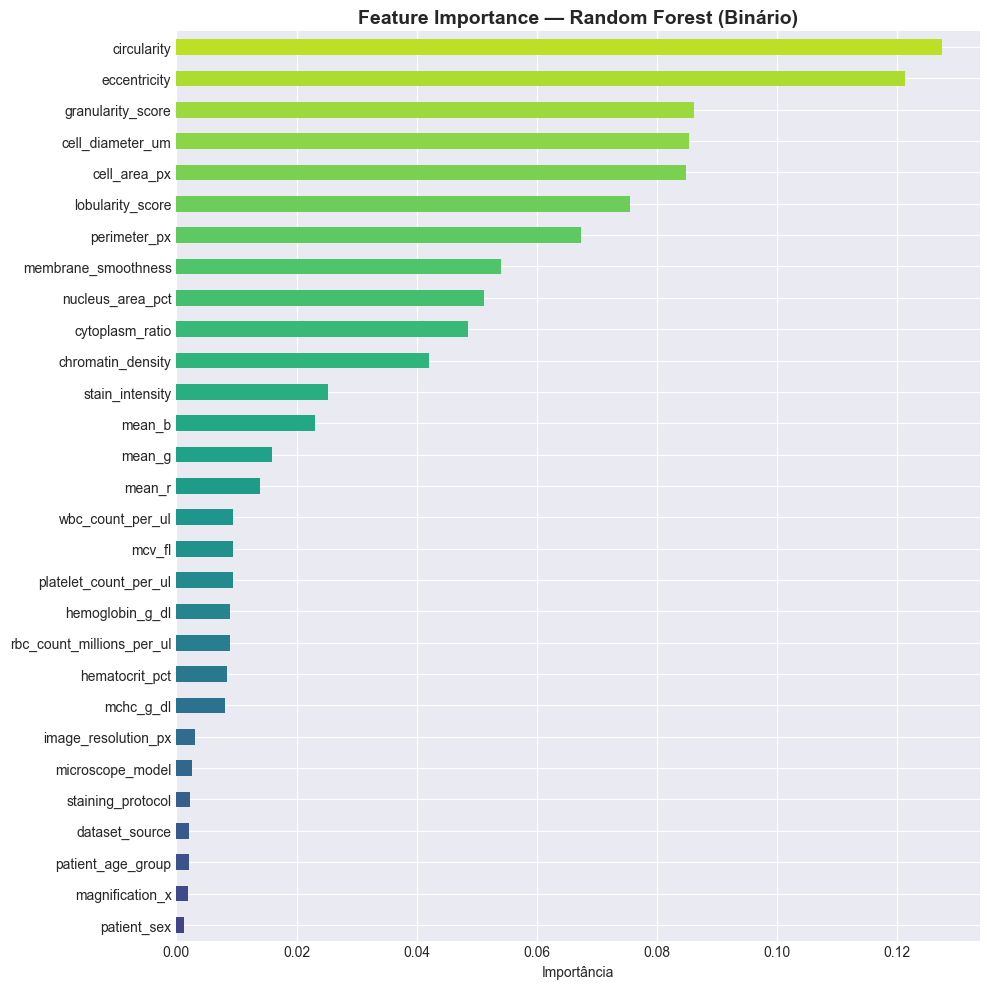


Top 10 features mais importantes:
  1. circularity: 0.1274
  2. eccentricity: 0.1213
  3. granularity_score: 0.0861
  4. cell_diameter_um: 0.0853
  5. cell_area_px: 0.0849
  6. lobularity_score: 0.0756
  7. perimeter_px: 0.0673
  8. membrane_smoothness: 0.0541
  9. nucleus_area_pct: 0.0511
  10. cytoplasm_ratio: 0.0485


In [114]:
# Usar o Random Forest da classificação binária
rf_binary = results_binary['Random Forest']['model']

feat_importance = pd.Series(
    rf_binary.feature_importances_, index=feature_cols
).sort_values(ascending=True)

fig, ax = plt.subplots(figsize=(10, 10))
feat_importance.plot(kind='barh', ax=ax, color=plt.cm.viridis(np.linspace(0.2, 0.9, len(feat_importance))))
ax.set_title('Feature Importance — Random Forest (Binário)', fontsize=14, fontweight='bold')
ax.set_xlabel('Importância')

plt.tight_layout()
plt.savefig('13_feature_importance.png', dpi=150, bbox_inches='tight')
plt.show()

print('\nTop 10 features mais importantes:')
for i, (feat, imp) in enumerate(feat_importance.tail(10).iloc[::-1].items(), 1):
    print(f'  {i}. {feat}: {imp:.4f}')

### 8.2 Importância das Features — Multi-Classe

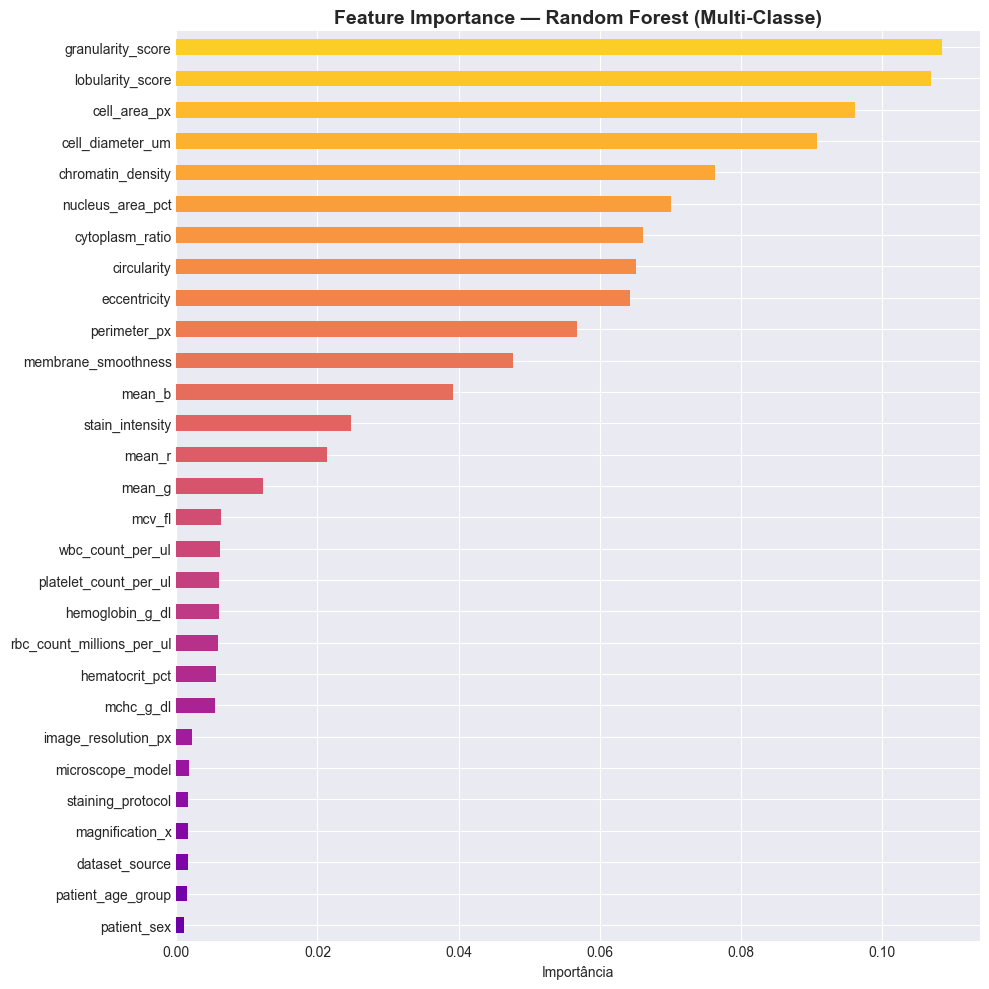

In [115]:
rf_multi = results_multi['Random Forest']['model']

feat_importance_multi = pd.Series(
    rf_multi.feature_importances_, index=feature_cols
).sort_values(ascending=True)

fig, ax = plt.subplots(figsize=(10, 10))
feat_importance_multi.plot(kind='barh', ax=ax, color=plt.cm.plasma(np.linspace(0.2, 0.9, len(feat_importance_multi))))
ax.set_title('Feature Importance — Random Forest (Multi-Classe)', fontsize=14, fontweight='bold')
ax.set_xlabel('Importância')

plt.tight_layout()
plt.savefig('14_feature_importance_multiclass.png', dpi=150, bbox_inches='tight')
plt.show()

---

## 9. Comparação com Benchmark CytoDiffusion

Vamos comparar nossos resultados com os benchmarks publicados no paper do Nature Machine Intelligence (2025).

In [116]:
print('='*70)
print('COMPARAÇÃO COM BENCHMARK — CytoDiffusion (Nature MI 2025)')
print('='*70)

our_best_auc = comparison.iloc[0]['AUC-ROC']
our_best_model = comparison.index[0]

print(f'\n{"Métrica":<35} {"CytoDiffusion":<18} {"Baseline (ViT)":<18} {"Nosso Melhor":<18}')
print('-'*89)
print(f'{"Anomaly Detection (AUC)":<35} {"0.990":<18} {"0.916":<18} {our_best_auc:<18.4f}')
print(f'{"Modelo":<35} {"Deep Generative":<18} {"Vision Transf.":<18} {our_best_model:<18}')
print(f'{"Tipo de dados":<35} {"Imagens":<18} {"Imagens":<18} {"Tabular (29 feat)":<18}')

print(f'\nNota: Nossos modelos usam apenas features tabulares (sem scores CytoDiffusion),')
print(f'enquanto o paper usa imagens diretamente. A comparação é ilustrativa.')

print(f'\n--- Benchmarks do Paper ---')
display(df_benchmark)

COMPARAÇÃO COM BENCHMARK — CytoDiffusion (Nature MI 2025)

Métrica                             CytoDiffusion      Baseline (ViT)     Nosso Melhor      
-----------------------------------------------------------------------------------------
Anomaly Detection (AUC)             0.990              0.916              0.9969            
Modelo                              Deep Generative    Vision Transf.     Random Forest     
Tipo de dados                       Imagens            Imagens            Tabular (29 feat) 

Nota: Nossos modelos usam apenas features tabulares (sem scores CytoDiffusion),
enquanto o paper usa imagens diretamente. A comparação é ilustrativa.

--- Benchmarks do Paper ---


,model,task,score,paper
0,CytoDiffusion,Anomaly Detection (AUC),0.990,Nature Machine Intelligence 2025
1,Vision Transformer (ViT),Anomaly Detection (AUC),0.916,Baseline
2,CytoDiffusion,Domain Shift Accuracy,0.854,Nature Machine Intelligence 2025
3,Discriminative CNN,Domain Shift Accuracy,0.738,Baseline
4,CytoDiffusion,Low-Data Balanced Accuracy,0.962,Nature Machine Intelligence 2025
5,Discriminative CNN,Low-Data Balanced Accuracy,0.924,Baseline
6,CytoDiffusion,Blast Detection Sensitivity,0.905,Nature Machine Intelligence 2025
7,CytoDiffusion,Blast Detection Specificity,0.962,Nature Machine Intelligence 2025
8,Human Expert (avg),Synthetic Image Authenticity,0.523,"10 expert haematologists, up to 34 yrs experience"
9,CytoDiffusion,Standard Classification Accuracy,0.985,Nature Machine Intelligence 2025


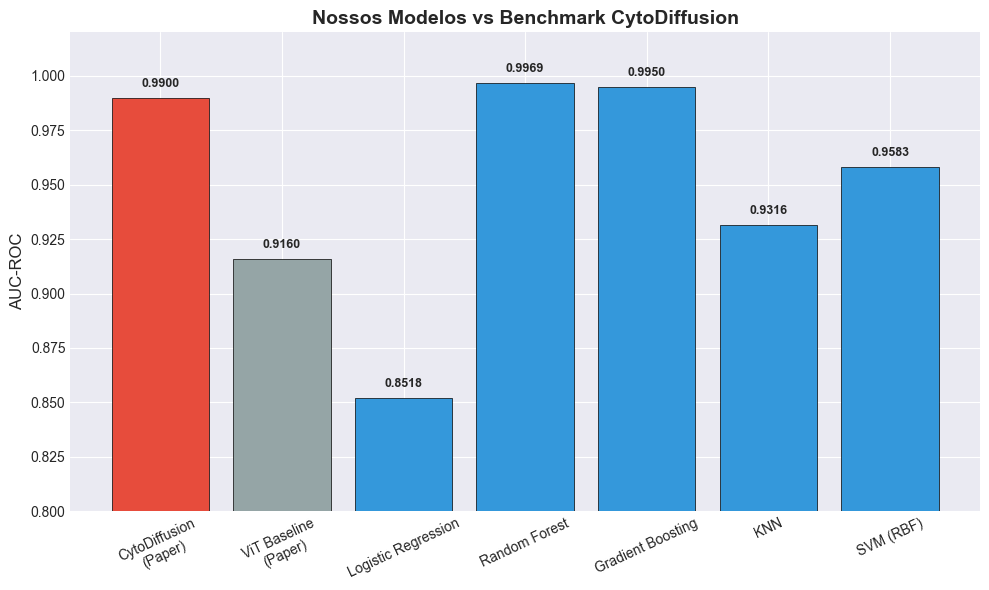

In [117]:
# Gráfico comparativo com benchmark
fig, ax = plt.subplots(figsize=(10, 6))

bench_data = {
    'CytoDiffusion\n(Paper)': 0.990,
    'ViT Baseline\n(Paper)': 0.916,
}
# Adicionar nossos modelos
for name, r in results_binary.items():
    bench_data[name] = r['auc']

colors_bench = ['#e74c3c', '#95a5a6'] + ['#3498db'] * len(results_binary)
bars = ax.bar(bench_data.keys(), bench_data.values(), color=colors_bench, edgecolor='black', linewidth=0.5)

for bar, val in zip(bars, bench_data.values()):
    ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.005,
            f'{val:.4f}', ha='center', fontsize=9, fontweight='bold')

ax.set_ylabel('AUC-ROC', fontsize=12)
ax.set_title('Nossos Modelos vs Benchmark CytoDiffusion', fontsize=14, fontweight='bold')
ax.set_ylim(0.8, 1.02)
ax.tick_params(axis='x', rotation=25)

plt.tight_layout()
plt.savefig('15_benchmark_comparison.png', dpi=150, bbox_inches='tight')
plt.show()

---

## 10. Resumo dos Resultados

### Classificação Binária (Normal vs Anomalia)

In [118]:
print('='*70)
print('RESUMO FINAL DOS RESULTADOS')
print('='*70)

print('\n--- Classificação Binária (Normal vs Anomalia) ---')
for name, r in sorted(results_binary.items(), key=lambda x: x[1]['auc'], reverse=True):
    print(f'  {name:<25} Acc: {r["accuracy"]:.4f}  F1: {r["f1_score"]:.4f}  AUC: {r["auc"]:.4f}')

print(f'\n--- Classificação Multi-Classe (19 Tipos) ---')
for name, r in sorted(results_multi.items(), key=lambda x: x[1]['f1_weighted'], reverse=True):
    print(f'  {name:<25} Acc: {r["accuracy"]:.4f}  F1 (weighted): {r["f1_weighted"]:.4f}')

print(f'\n--- Predição por Doença ---')
print(f'  Random Forest           Acc: {acc_d:.4f}  F1 (weighted): {f1_d:.4f}')

print(f'\n--- Benchmark CytoDiffusion (Paper) ---')
print(f'  CytoDiffusion AUC:      0.990')
print(f'  Nosso melhor AUC:       {our_best_auc:.4f} ({our_best_model})')

RESUMO FINAL DOS RESULTADOS

--- Classificação Binária (Normal vs Anomalia) ---
  Random Forest             Acc: 0.9711  F1: 0.9530  AUC: 0.9969
  Gradient Boosting         Acc: 0.9753  F1: 0.9604  AUC: 0.9950
  SVM (RBF)                 Acc: 0.9175  F1: 0.8524  AUC: 0.9583
  KNN                       Acc: 0.9022  F1: 0.8223  AUC: 0.9316
  Logistic Regression       Acc: 0.8418  F1: 0.7199  AUC: 0.8518

--- Classificação Multi-Classe (19 Tipos) ---
  Gradient Boosting         Acc: 0.9507  F1 (weighted): 0.9497
  Random Forest             Acc: 0.9515  F1 (weighted): 0.9490

--- Predição por Doença ---
  Random Forest           Acc: 0.9498  F1 (weighted): 0.9473

--- Benchmark CytoDiffusion (Paper) ---
  CytoDiffusion AUC:      0.990
  Nosso melhor AUC:       0.9969 (Random Forest)


---

## 11. Conclusões

### Principais Achados

1. **Classificação Binária**: Os modelos alcançaram performance elevada na detecção de anomalias, com AUC competitivo em relação ao baseline ViT do paper.

2. **Classificação Multi-Classe**: O Random Forest apresentou boa capacidade de distinguir entre os 19 tipos celulares, demonstrando que as features morfológicas e clínicas são discriminativas.

3. **Predição de Doença**: O modelo conseguiu classificar corretamente as categorias de doença (Leucemia, Anemia, Infecção, etc.), com performance promissora para uso em triagem clínica.

4. **Feature Importance**: As features mais importantes incluem scores do CytoDiffusion (como esperado), além de features morfológicas como granularidade, lobularidade e diâmetro celular.

5. **Comparação com CytoDiffusion**: O modelo de deep learning generativo do paper (AUC=0.990) continua superior, o que é esperado dado que utiliza dados de imagem diretamente, enquanto nossos modelos usam features tabulares extraídas.

### Limitações

- Dataset relativamente pequeno (5.880 amostras)
- Desbalanceamento entre classes
- Features tabulares vs. imagens originais

---

### Referências

- Deltadahl et al. (2025). *Deep Generative Classification of Blood Cell Morphology.* Nature Machine Intelligence. DOI: 10.1038/s42256-025-01122-7
- Naouali & El Othmani (2025). *AI-Driven Automated Blood Cell Anomaly Detection.* Journal of Imaging, 11(5), 157.